In [ ]:
#!pip install torchaudio scikit-learn --quiet

#
#  CELL 1 — Mount Google Drive


from google.colab import drive
import os
import shutil



#   CELL 2 — GPU Check


#
# Then run this cell to confirm:

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if device.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("  No GPU detected. Go to Runtime → Change runtime type → GPU")

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Configuration                                     ║
# ╚══════════════════════════════════════════════════════════════╝

import os
from pathlib import Path

# ── Your data path ────────────────────────────────────────────
DATA_PATH = "/content/drive/MyDrive/DSP Project/esc50_data/ESC-50-master"

DRIVE_BASE  = Path(DATA_PATH)
AUDIO_DIR   = DRIVE_BASE / "audio"
META_PATH   = DRIVE_BASE / "meta" / "esc50.csv"

OUT_DIR     = Path("/content/drive/MyDrive/DSP Project/experiment_cnn14")
OUT_MODELS  = OUT_DIR / "models"
OUT_LOGS    = OUT_DIR / "logs"
OUT_RESULTS = OUT_DIR / "results"

# ── Reproducibility ───────────────────────────────────────────
SEED = 42

# ── Audio ─────────────────────────────────────────────────────
SR_ORIGINAL  = 44_100
SR_MODEL     = 32_000
CLIP_SAMPLES = 160_000        # 5.0 s × 32,000 Hz
CLIP_DURATION = 5.0

# ── Log-Mel Spectrogram (fixed) ───────────────────────────────
N_FFT       = 1024       # balanced for frq and tim    30ms, 30hz
HOP_LENGTH  = 320        #10ms
WIN_LENGTH  = 1024
N_MELS      = 64    #CNN14 expects this
FMIN        = 50
FMAX        = 14_000         #32k/2=16k~14k

# ── Model ─────────────────────────────────────────────────────
NUM_CLASSES  = 50
PRETRAINED_URL = (
    "https://zenodo.org/record/3987831/files/"
    "Cnn14_mAP%3D0.431.pth"
)
PRETRAINED_PATH = OUT_DIR / "Cnn14_mAP=0.431.pth"

# ── Cross-validation ──────────────────────────────────────────
FOLDS = [1, 2, 3, 4, 5]

# ── Training phases ───────────────────────────────────────────
PHASE1_EPOCHS       = 10
PHASE1_LR           = 1e-3
PHASE1_WEIGHT_DECAY = 1e-4

PHASE2_EPOCHS       = 20
PHASE2_LR_BACKBONE  = 1e-5
PHASE2_LR_HEAD      = 1e-4
PHASE2_WEIGHT_DECAY = 1e-4

PHASE3_EPOCHS       = 10
PHASE3_LR           = 5e-6
PHASE3_WEIGHT_DECAY = 1e-4

# ── Regularization ────────────────────────────────────────────
DROPOUT_CLASSIFIER  = 0.5
EARLY_STOP_PATIENCE = 5

# ── Optimization ──────────────────────────────────────────────
BATCH_SIZE   = 32
SCHEDULER    = "cosine"
STEP_SIZE    = 10
STEP_GAMMA   = 0.1

# ── Logging ───────────────────────────────────────────────────
LOG_EVERY_N_BATCHES = 20

print("✅ Configuration loaded")
print(f"   Data  : {DRIVE_BASE}")
print(f"   Output: {OUT_DIR}")
print(f"   Device: {device}")

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 4 — Dataset utilities                                 ║
# ╚══════════════════════════════════════════════════════════════╝

import numpy as np
import pandas as pd
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset
from tqdm import tqdm


def load_and_resample(path: str) -> torch.Tensor:
    waveform, sr = torchaudio.load(path)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != SR_MODEL:
        waveform = T.Resample(orig_freq=sr, new_freq=SR_MODEL)(waveform)
    return waveform


def fix_clip_length(waveform: torch.Tensor) -> torch.Tensor:
    n      = waveform.shape[-1]
    target = CLIP_SAMPLES
    if n < target:
        waveform = torch.nn.functional.pad(waveform, (0, target - n))
    elif n > target:
        start    = (n - target) // 2
        waveform = waveform[:, start: start + target]
    return waveform
#CNN14 accepts log mel spectogram

def build_mel_transform() -> torch.nn.Sequential:
    mel = T.MelSpectrogram(
        sample_rate=SR_MODEL, n_fft=N_FFT, win_length=WIN_LENGTH,
        hop_length=HOP_LENGTH, f_min=FMIN, f_max=FMAX,
        n_mels=N_MELS, power=2.0,
    )
    return torch.nn.Sequential(mel, T.AmplitudeToDB(stype="power", top_db=80.0))


_MEL_TRANSFORM = build_mel_transform()


def waveform_to_logmel(waveform: torch.Tensor) -> torch.Tensor:
    with torch.no_grad():
        return _MEL_TRANSFORM(waveform)


def compute_train_stats(df_train: pd.DataFrame):
    print("  Computing train-set mean/std …")
    running_sum = running_sq = running_n = 0.0
    for _, row in tqdm(df_train.iterrows(), total=len(df_train), desc="  Stats"):
        wav  = fix_clip_length(load_and_resample(row["file_path"]))
        vals = waveform_to_logmel(wav).numpy().ravel()
        running_sum += vals.sum()
        running_sq  += (vals ** 2).sum()
        running_n   += len(vals)
    mean = running_sum / running_n
    std  = max(np.sqrt(running_sq / running_n - mean ** 2), 1e-6)
    print(f"  mean={mean:.4f}  std={std:.4f}")
    return float(mean), float(std)


class ESC50Dataset(Dataset):
    def __init__(self, df, mean, std, label_to_idx):
        self.df           = df.reset_index(drop=True)
        self.mean         = mean
        self.std          = std
        self.label_to_idx = label_to_idx

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        wav  = fix_clip_length(load_and_resample(row["file_path"]))
        spec = (waveform_to_logmel(wav) - self.mean) / self.std
        lbl  = self.label_to_idx[row["category"]]
        return spec, torch.tensor(lbl, dtype=torch.long)


def build_dataloaders(df_train, df_test, label_to_idx, mean, std):
    train_ds = ESC50Dataset(df_train, mean, std, label_to_idx)
    test_ds  = ESC50Dataset(df_test,  mean, std, label_to_idx)
    kw = dict(batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
    return (
        torch.utils.data.DataLoader(train_ds, shuffle=True,  **kw),
        torch.utils.data.DataLoader(test_ds,  shuffle=False, **kw),
    )


def load_metadata() -> pd.DataFrame:
    df = pd.read_csv(META_PATH)
    df["file_path"] = df["filename"].apply(lambda f: str(AUDIO_DIR / f))
    return df


def build_label_map(df: pd.DataFrame) -> dict:
    cats = sorted(df["category"].unique())
    return {cat: idx for idx, cat in enumerate(cats)}


print(" Dataset utilities loaded")

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Model (CNN14 backbone + ESC-50 head)              ║
# ╚══════════════════════════════════════════════════════════════╝

import torch.nn as nn
import torch.nn.functional as F
import urllib.request


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.bn2   = nn.BatchNorm2d(out_ch)

    def forward(self, x, pool_size=(2,2), pool_type="avg"):
        x = F.relu_(self.bn1(self.conv1(x)))
        x = F.relu_(self.bn2(self.conv2(x)))
        if pool_type == "max":
            x = F.max_pool2d(x, pool_size)
        elif pool_type == "avg":
            x = F.avg_pool2d(x, pool_size)
        elif pool_type == "avg+max":
            x = F.avg_pool2d(x, pool_size) + F.max_pool2d(x, pool_size)
        return x


class Cnn14Backbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.bn0         = nn.BatchNorm2d(64)
        self.conv_block1 = ConvBlock(1,    64)
        self.conv_block2 = ConvBlock(64,  128)
        self.conv_block3 = ConvBlock(128, 256)
        self.conv_block4 = ConvBlock(256, 512)
        self.conv_block5 = ConvBlock(512, 1024)
        self.conv_block6 = ConvBlock(1024, 2048)
        self.fc1         = nn.Linear(2048, 2048, bias=True)

    def forward(self, x):
        x = x.transpose(2, 3)
        x = x.transpose(1, 3)
        x = self.bn0(x)
        x = x.transpose(1, 3)
        for blk in [self.conv_block1, self.conv_block2,
                    self.conv_block3, self.conv_block4, self.conv_block5]:
            x = F.dropout(blk(x, pool_size=(2,2), pool_type="avg"),
                          p=0.2, training=self.training)
        x = F.dropout(self.conv_block6(x, pool_size=(1,1), pool_type="avg"),
                      p=0.2, training=self.training)
        x = (torch.mean(x, dim=3) + torch.amax(x, dim=3)) / 2
        x = torch.mean(x, dim=2)
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu_(self.fc1(x))
        x = F.dropout(x, p=0.5, training=self.training)
        return x


class CNN14ESC50(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone   = Cnn14Backbone()
        self.classifier = nn.Sequential(
            nn.Dropout(p=DROPOUT_CLASSIFIER),
            nn.Linear(2048, NUM_CLASSES, bias=True),
        )

    def forward(self, x):
        return self.classifier(self.backbone(x))


def download_pretrained_weights():
    out = PRETRAINED_PATH
    out.parent.mkdir(parents=True, exist_ok=True)
    if out.exists():
        print(f"  Weights found: {out}")
        return
    print("  Downloading CNN14 pretrained weights …")
    urllib.request.urlretrieve(PRETRAINED_URL, out)
    print(f"  Saved: {out}")


def load_pretrained_cnn14(model, checkpoint_path, device):
    ckpt        = torch.load(checkpoint_path, map_location=device)
    pre_state   = ckpt["model"]
    model_state = model.state_dict()
    loaded, skipped = [], []
    for key, val in pre_state.items():
        mk = f"backbone.{key}"
        if mk in model_state and model_state[mk].shape == val.shape:
            model_state[mk] = val
            loaded.append(mk)
        else:
            skipped.append(key)
    model.load_state_dict(model_state)
    print(f"  Loaded {len(loaded)} tensors, skipped {len(skipped)}")
    return model


def freeze_backbone(model):
    for p in model.backbone.parameters():  p.requires_grad = False
    for p in model.classifier.parameters(): p.requires_grad = True
    t = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Phase 1 — backbone frozen. Trainable: {t:,}")


def unfreeze_last_block(model):
    for p in model.backbone.parameters():  p.requires_grad = False
    for p in model.backbone.conv_block6.parameters(): p.requires_grad = True
    for p in model.backbone.fc1.parameters():         p.requires_grad = True
    for p in model.classifier.parameters():           p.requires_grad = True
    t = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Phase 2 — conv_block6+fc1 unfrozen. Trainable: {t:,}")


def unfreeze_full_model(model):
    for p in model.parameters(): p.requires_grad = True
    t = sum(p.numel() for p in model.parameters())
    print(f"  Phase 3 — full model unfrozen. Trainable: {t:,}")


def build_phase1_optimizer(model):
    return torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=PHASE1_LR, weight_decay=PHASE1_WEIGHT_DECAY)


def build_phase2_optimizer(model):
    bb = list(model.backbone.conv_block6.parameters()) + \
         list(model.backbone.fc1.parameters())
    hd = list(model.classifier.parameters())
    return torch.optim.AdamW(
        [{"params": bb, "lr": PHASE2_LR_BACKBONE},
         {"params": hd, "lr": PHASE2_LR_HEAD}],
        weight_decay=PHASE2_WEIGHT_DECAY)


def build_phase3_optimizer(model):
    return torch.optim.AdamW(
        model.parameters(), lr=PHASE3_LR, weight_decay=PHASE3_WEIGHT_DECAY)


print(" Model utilities loaded")

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 6 — Evaluation utilities                              ║
# ╚══════════════════════════════════════════════════════════════╝

import json
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


def evaluate_model(model, loader, device, label_to_idx):
    model.eval()
    idx_to_label = {v: k for k, v in label_to_idx.items()}
    class_names  = [idx_to_label[i] for i in range(len(label_to_idx))]
    all_preds, all_labels = [], []
    with torch.no_grad():
        for specs, labels in loader:
            specs = specs.to(device, non_blocking=True)
            preds = F.softmax(model(specs), dim=1).argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    acc  = accuracy_score(all_labels, all_preds)
    cm   = confusion_matrix(all_labels, all_preds)
    rpt  = classification_report(all_labels, all_preds,
                                 target_names=class_names,
                                 output_dict=True, zero_division=0)
    return acc, cm, rpt


def print_fold_report(fold, accuracy, conf_matrix, class_report, label_to_idx):
    idx_to_label = {v: k for k, v in label_to_idx.items()}
    per_class_recall = (conf_matrix.diagonal() /
                        conf_matrix.sum(axis=1).clip(min=1))
    sorted_idx = np.argsort(per_class_recall)
    print(f"\n  {'─'*55}")
    print(f"  FOLD {fold} EVALUATION REPORT")
    print(f"  {'─'*55}")
    print(f"  Accuracy : {accuracy*100:.2f}%")
    print(f"\n  Worst 5 classes:")
    for i in sorted_idx[:5]:
        print(f"    {idx_to_label[i]:<30} recall={per_class_recall[i]*100:.1f}%")
    print(f"\n  Best 5 classes:")
    for i in sorted_idx[-5:][::-1]:
        print(f"    {idx_to_label[i]:<30} recall={per_class_recall[i]*100:.1f}%")
    OUT_RESULTS.mkdir(parents=True, exist_ok=True)
    np.save(OUT_RESULTS / f"fold{fold}_confusion.npy", conf_matrix)
    with open(OUT_RESULTS / f"fold{fold}_class_report.json", "w") as f:
        json.dump(class_report, f, indent=2)
    print(f"\n  Reports saved to {OUT_RESULTS}")


def print_cv_report(fold_results):
    fold_accs = [r["final_acc"] for r in fold_results]
    mean_acc  = np.mean(fold_accs)
    std_acc   = np.std(fold_accs)
    print(f"\n{'='*60}")
    print(f"  CROSS-VALIDATION SUMMARY")
    print(f"{'='*60}")
    for r in fold_results:
        print(f"  Fold {r['fold']}  acc={r['final_acc']*100:.2f}%  "
              f"best_p1={r['best_p1']*100:.1f}%  "
              f"best_p2={r['best_p2']*100:.1f}%  "
              f"best_p3={r['best_p3']*100:.1f}%")
    print(f"\n  Mean : {mean_acc*100:.2f}%")
    print(f"  Std  : {std_acc*100:.2f}%")
    print(f"  Range: {min(fold_accs)*100:.2f}% – {max(fold_accs)*100:.2f}%")
    if mean_acc >= 0.92:   print("\n   Target met (≥92%)")
    elif mean_acc >= 0.90: print("\n    Below 92% target")
    else:                  print("\n   Below 90% — review preprocessing")
    print(f"{'='*60}")


print("✅ Evaluation utilities loaded")

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 7 — Training loop                                     ║
# ╚══════════════════════════════════════════════════════════════╝

import random
import time
from torch.optim.lr_scheduler import CosineAnnealingLR, StepLR


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


def build_scheduler(optimizer, n_epochs):
    if SCHEDULER == "cosine":
        return CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=0)
    return StepLR(optimizer, step_size=STEP_SIZE, gamma=STEP_GAMMA)


class EarlyStopping:
    def __init__(self, patience, save_path):
        self.patience   = patience
        self.save_path  = save_path
        self.best_acc   = -1.0
        self.best_epoch = -1
        self.counter    = 0
        self.stop       = False

    def step(self, val_acc, epoch, model):
        if val_acc > self.best_acc:
            self.best_acc   = val_acc
            self.best_epoch = epoch
            self.counter    = 0
            torch.save(model.state_dict(), self.save_path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


def train_one_epoch(model, loader, optimizer, criterion, device, epoch, fold):
    model.train()
    total_loss, n_batches = 0.0, 0
    for batch_idx, (specs, labels) in enumerate(loader):
        specs  = specs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad()
        loss = criterion(model(specs), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        n_batches  += 1
        if (batch_idx + 1) % LOG_EVERY_N_BATCHES == 0:
            print(f"    [Fold {fold} | Epoch {epoch:03d} | "
                  f"Batch {batch_idx+1}/{len(loader)}] loss={loss.item():.4f}")
    return total_loss / max(n_batches, 1)


def run_phase(model, train_loader, test_loader, optimizer, criterion,
              n_epochs, phase_name, fold, device, early_stopper,
              log_records, label_to_idx):
    scheduler = build_scheduler(optimizer, n_epochs)
    print(f"\n  {'─'*55}")
    print(f"  {phase_name} | Fold {fold} | {n_epochs} epochs")
    print(f"  {'─'*55}")
    for epoch in range(1, n_epochs + 1):
        t0         = time.time()
        train_loss = train_one_epoch(model, train_loader, optimizer,
                                     criterion, device, epoch, fold)
        val_acc, _, _ = evaluate_model(model, test_loader, device, label_to_idx)
        lr = optimizer.param_groups[0]["lr"]
        print(f"  [{phase_name}] Fold={fold} Epoch={epoch:03d} | "
              f"loss={train_loss:.4f} | acc={val_acc*100:.2f}% | "
              f"lr={lr:.2e} | {time.time()-t0:.1f}s")
        log_records.append({"fold": fold, "phase": phase_name, "epoch": epoch,
                            "train_loss": round(train_loss, 6),
                            "val_acc": round(val_acc, 6), "lr": lr})
        early_stopper.step(val_acc, epoch, model)
        if early_stopper.stop:
            print(f"   Early stop @ epoch {epoch}  "
                  f"best={early_stopper.best_acc*100:.2f}%")
            break
        scheduler.step()
    return early_stopper.best_acc


def train_fold(fold, df, label_to_idx, device):
    print(f"\n{'='*60}\n  FOLD {fold}\n{'='*60}")
    df_train = df[df["fold"] != fold].reset_index(drop=True)
    df_test  = df[df["fold"] == fold].reset_index(drop=True)
    print(f"  Train: {len(df_train)}  Test: {len(df_test)}")

    mean, std = compute_train_stats(df_train)
    train_loader, test_loader = build_dataloaders(
        df_train, df_test, label_to_idx, mean, std)

    model     = load_pretrained_cnn14(CNN14ESC50().to(device),
                                      PRETRAINED_PATH, device)
    criterion = nn.CrossEntropyLoss()
    log_records = []
    OUT_MODELS.mkdir(parents=True, exist_ok=True)

    # ── Phase 1 ──────────────────────────────────────────────
    freeze_backbone(model)
    stopper_p1 = EarlyStopping(EARLY_STOP_PATIENCE,
                                OUT_MODELS / f"fold{fold}_phase1_best.pth")
    best_p1 = run_phase(model, train_loader, test_loader,
                        build_phase1_optimizer(model), criterion,
                        PHASE1_EPOCHS, "Phase1-WarmUp", fold, device,
                        stopper_p1, log_records, label_to_idx)
    model.load_state_dict(torch.load(
        OUT_MODELS / f"fold{fold}_phase1_best.pth", map_location=device))
    print(f"\n  Phase 1 best: {best_p1*100:.2f}%")

    # ── Phase 2 ──────────────────────────────────────────────
    unfreeze_last_block(model)
    stopper_p2 = EarlyStopping(EARLY_STOP_PATIENCE,
                                OUT_MODELS / f"fold{fold}_phase2_best.pth")
    best_p2 = run_phase(model, train_loader, test_loader,
                        build_phase2_optimizer(model), criterion,
                        PHASE2_EPOCHS, "Phase2-PartialFT", fold, device,
                        stopper_p2, log_records, label_to_idx)
    model.load_state_dict(torch.load(
        OUT_MODELS / f"fold{fold}_phase2_best.pth", map_location=device))
    print(f"\n  Phase 2 best: {best_p2*100:.2f}%")

    # ── Phase 3 (optional) ───────────────────────────────────
    best_p3 = best_p2
    if best_p2 < 0.90:
        print(f"\n  Phase 2 < 90% → running Phase 3 (full fine-tune)")
        unfreeze_full_model(model)
        stopper_p3 = EarlyStopping(EARLY_STOP_PATIENCE,
                                    OUT_MODELS / f"fold{fold}_phase3_best.pth")
        best_p3 = run_phase(model, train_loader, test_loader,
                            build_phase3_optimizer(model), criterion,
                            PHASE3_EPOCHS, "Phase3-FullFT", fold, device,
                            stopper_p3, log_records, label_to_idx)
        ckpt = (OUT_MODELS / f"fold{fold}_phase3_best.pth"
                if best_p3 > best_p2
                else OUT_MODELS / f"fold{fold}_phase2_best.pth")
        model.load_state_dict(torch.load(ckpt, map_location=device))
        if best_p3 <= best_p2:
            best_p3 = best_p2
            print("  Phase 3 degraded → reverted to Phase 2")
    else:
        print(f"\n  Phase 2 ≥ 90% → Phase 3 skipped")

    # ── Final eval ────────────────────────────────────────────
    final_acc, conf_matrix, class_report = evaluate_model(
        model, test_loader, device, label_to_idx)
    print(f"\n  ✅ Fold {fold} done | final={final_acc*100:.2f}%")

    torch.save(model.state_dict(), OUT_MODELS / f"fold{fold}_final.pth")
    log_path = OUT_LOGS / f"fold{fold}_log.json"
    log_path.parent.mkdir(parents=True, exist_ok=True)
    with open(log_path, "w") as f:
        json.dump(log_records, f, indent=2)

    return {"fold": fold, "final_acc": final_acc,
            "best_p1": best_p1, "best_p2": best_p2, "best_p3": best_p3,
            "best_overall": max(best_p1, best_p2, best_p3),
            "confusion": conf_matrix, "class_report": class_report,
            "mean": mean, "std": std}


print(" Training utilities loaded")

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 8 — Verify model shape (quick sanity check)           ║
# ╚══════════════════════════════════════════════════════════════╝

_m = CNN14ESC50().to(device)
_d = torch.randn(2, 1, N_MELS, 501).to(device)
with torch.no_grad():
    _o = _m(_d)
assert _o.shape == (2, NUM_CLASSES), f"Shape mismatch: {_o.shape}"
print(f" Model OK — output shape: {tuple(_o.shape)}")
del _m, _d, _o

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 9 — Download pretrained weights                       ║
# ╚══════════════════════════════════════════════════════════════╝

for d in [OUT_MODELS, OUT_LOGS, OUT_RESULTS]:
    d.mkdir(parents=True, exist_ok=True)

download_pretrained_weights()

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 10 — Run 5-fold cross-validation                    ║
# ╚══════════════════════════════════════════════════════════════╝

set_seed(SEED)

df           = load_metadata()
label_to_idx = build_label_map(df)
print(f"Dataset: {len(df)} clips | {len(label_to_idx)} classes")

with open(OUT_RESULTS / "label_to_idx.json", "w") as f:
    json.dump(label_to_idx, f, indent=2)

fold_results = []
for fold in FOLDS:
    result = train_fold(fold, df, label_to_idx, device)
    fold_results.append(result)
    print_fold_report(fold, result["final_acc"],
                      result["confusion"], result["class_report"],
                      label_to_idx)

 Fold 4 Retrain to prepare for noise experiment
                                                                              
  Pipeline:                                                                   
    • Training   : 90% of folds {1,2,3,5}  (stratified random split)         
    • Validation : 10% of folds {1,2,3,5}  (model selection, early stopping)
    • Test       : fold 4 only  (held-out, evaluated ONCE at the end)         
                                                                              
  Reporting:                                                                  
   A) Training accuracy / loss curve                                         
    B) Inner validation accuracy  → model selection signal                    
    C) Outer test accuracy        → true generalization estimate  

In [ ]:
# !pip install torchaudio scikit-learn --quiet


# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 1 — Mount Google Drive                                ║
# ╚══════════════════════════════════════════════════════════════╝

from google.colab import drive
import os, shutil



# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 2 — GPU check                                         ║
# ╚══════════════════════════════════════════════════════════════╝
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if device.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  No GPU detected — training will be slow.")

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Configuration                                     ║
# ╚══════════════════════════════════════════════════════════════╝

import os
from pathlib import Path
from datetime import datetime

# ── Paths  ──
DATA_PATH   = "/content/drive/MyDrive/DSP Project/esc50_data/ESC-50-master"
DRIVE_BASE  = Path(DATA_PATH)
AUDIO_DIR   = DRIVE_BASE / "audio"
META_PATH   = DRIVE_BASE / "meta" / "esc50.csv"

# Pretrained weights: p
PRETRAINED_PATH = Path(
    "/content/drive/MyDrive/DSP Project/"
    "experiment_cnn14_v2_optimized_20260428_2024/"
    "Cnn14_mAP=0.431.pth"
)
# Fallback download URL in case the path above is missing
PRETRAINED_URL = (
    "https://zenodo.org/record/3987831/files/"
    "Cnn14_mAP%3D0.431.pth"
)

# ── Output folder
OUT_DIR     = Path("/content/drive/MyDrive/DSP Project/overfitting_check")
OUT_MODELS  = OUT_DIR / "models"
OUT_LOGS    = OUT_DIR / "logs"
OUT_RESULTS = OUT_DIR / "results"
for _d in [OUT_MODELS, OUT_LOGS, OUT_RESULTS]:
    _d.mkdir(parents=True, exist_ok=True)

print(f"📁 Output folder : {OUT_DIR}")

# ── Which fold is the outer test set ────────────────────────────────────────
OUTER_TEST_FOLD = 4
INNER_VAL_FRAC  = 0.10
INNER_VAL_SEED  = 42

SEED = 42

# ── Audio / spectrogram settings
SR_ORIGINAL  = 44_100
SR_MODEL     = 32_000
CLIP_SAMPLES = 160_000
CLIP_DURATION = 5.0

N_FFT       = 1024
HOP_LENGTH  = 320
WIN_LENGTH  = 1024
N_MELS      = 64
FMIN        = 50
FMAX        = 14_000

NUM_CLASSES  = 50

# ── Training phases
PHASE1_EPOCHS       = 15
PHASE1_LR           = 1e-3
PHASE1_WEIGHT_DECAY = 1e-4

PHASE2_EPOCHS       = 40
PHASE2_WEIGHT_DECAY = 1e-4
PHASE2_LR_LOW       = 5e-6
PHASE2_LR_HIGH      = 2e-5
PHASE2_LR_HEAD      = 2e-4

PHASE3_EPOCHS       = 20
PHASE3_LR_LOW       = 1e-6
PHASE3_LR_MID       = 3e-6
PHASE3_LR_HIGH      = 1e-5
PHASE3_LR_HEAD      = 1e-4
PHASE3_WEIGHT_DECAY = 1e-4

# ── Augmentation
FREQ_MASK_PARAM = 12
TIME_MASK_PARAM = 30
N_FREQ_MASKS    = 3
N_TIME_MASKS    = 3

MIXUP_ALPHA   = 0.4
CUTMIX_ALPHA  = 1.0
MIXUP_PROB    = 0.5
CUTMIX_PROB   = 0.5

LABEL_SMOOTHING = 0.1
BATCH_SIZE      = 48
GRAD_CLIP_NORM  = 1.0
WARMUP_EPOCHS   = 3
DROPOUT_CLASSIFIER  = 0.5
EARLY_STOP_PATIENCE = 7
SCHEDULER    = "cosine"
STEP_SIZE    = 10
STEP_GAMMA   = 0.1
LOG_EVERY_N_BATCHES = 20

print("✅ Configuration loaded")
print(f"   Outer test fold : {OUTER_TEST_FOLD}")
print(f"   Inner val frac  : {INNER_VAL_FRAC} (stratified random)")
print(f"   Output          : {OUT_DIR}")
print(f"   Device          : {device}")

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 4 — Dataset utilities                                 ║
# ╚══════════════════════════════════════════════════════════════╝

import numpy as np
import pandas as pd
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset
from tqdm import tqdm


def load_and_resample(path: str) -> torch.Tensor:
    waveform, sr = torchaudio.load(path)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != SR_MODEL:
        waveform = T.Resample(orig_freq=sr, new_freq=SR_MODEL)(waveform)
    return waveform


def fix_clip_length(waveform: torch.Tensor) -> torch.Tensor:
    n      = waveform.shape[-1]
    target = CLIP_SAMPLES
    if n < target:
        waveform = torch.nn.functional.pad(waveform, (0, target - n))
    elif n > target:
        start    = (n - target) // 2
        waveform = waveform[:, start: start + target]
    return waveform


def random_time_shift(waveform: torch.Tensor, max_shift_frac: float = 0.1) -> torch.Tensor:
    """Circular shift the waveform by a random amount (max 10% of length)."""
    n     = waveform.shape[-1]
    shift = int(np.random.uniform(-max_shift_frac, max_shift_frac) * n)
    return torch.roll(waveform, shift, dims=-1)


def build_mel_transform() -> torch.nn.Sequential:
    mel = T.MelSpectrogram(
        sample_rate=SR_MODEL, n_fft=N_FFT, win_length=WIN_LENGTH,
        hop_length=HOP_LENGTH, f_min=FMIN, f_max=FMAX,
        n_mels=N_MELS, power=2.0,
    )
    return torch.nn.Sequential(mel, T.AmplitudeToDB(stype="power", top_db=80.0))


def build_spec_augment():
    masks = []
    for _ in range(N_FREQ_MASKS):
        masks.append(T.FrequencyMasking(freq_mask_param=FREQ_MASK_PARAM))
    for _ in range(N_TIME_MASKS):
        masks.append(T.TimeMasking(time_mask_param=TIME_MASK_PARAM))
    return torch.nn.Sequential(*masks)

_SPEC_AUGMENT  = build_spec_augment()
_MEL_TRANSFORM = build_mel_transform()


def waveform_to_logmel(waveform: torch.Tensor) -> torch.Tensor:
    with torch.no_grad():
        return _MEL_TRANSFORM(waveform)


class ESC50Dataset(Dataset):
    def __init__(self, df, mean, std, label_to_idx, is_train: bool = False):
        self.df           = df.reset_index(drop=True)
        self.mean         = mean
        self.std          = std
        self.label_to_idx = label_to_idx
        self.is_train     = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        wav = fix_clip_length(load_and_resample(row["file_path"]))

        if self.is_train:
            wav = random_time_shift(wav, max_shift_frac=0.1)

        spec = waveform_to_logmel(wav)

        if self.is_train:
            spec = _SPEC_AUGMENT(spec)

        spec = (spec - self.mean) / self.std
        lbl  = self.label_to_idx[row["category"]]
        return spec, torch.tensor(lbl, dtype=torch.long)


def build_dataloaders(df_train, df_val, df_test, label_to_idx, mean, std):
    """
    Returns three loaders:
      train_loader  — augmented, shuffled
      val_loader    — clean, not shuffled  (inner split, used for early stopping)
      test_loader   — clean, not shuffled  (outer fold 4, evaluated ONCE at end)
    """
    train_ds = ESC50Dataset(df_train, mean, std, label_to_idx, is_train=True)
    val_ds   = ESC50Dataset(df_val,   mean, std, label_to_idx, is_train=False)
    test_ds  = ESC50Dataset(df_test,  mean, std, label_to_idx, is_train=False)
    kw = dict(batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
    return (
        torch.utils.data.DataLoader(train_ds, shuffle=True,  **kw),
        torch.utils.data.DataLoader(val_ds,   shuffle=False, **kw),
        torch.utils.data.DataLoader(test_ds,  shuffle=False, **kw),
    )


def load_metadata() -> pd.DataFrame:
    df = pd.read_csv(META_PATH)
    df["file_path"] = df["filename"].apply(lambda f: str(AUDIO_DIR / f))
    return df

def pre_emphasis(waveform: torch.Tensor, coef: float = 0.97) -> torch.Tensor:
    """Apply pre-emphasis filter: y[t] = x[t] - coef * x[t-1]."""
    emphasized = torch.cat([waveform[:, :1], waveform[:, 1:] - coef * waveform[:, :-1]], dim=1)
    return emphasized

def build_label_map(df: pd.DataFrame) -> dict:
    cats = sorted(df["category"].unique())
    return {cat: idx for idx, cat in enumerate(cats)}


print("✅ Dataset utilities loaded")


# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 4b — Inner validation split (stratified random)       ║
# ╚══════════════════════════════════════════════════════════════╝

from sklearn.model_selection import train_test_split


def make_inner_split(df_dev: pd.DataFrame, val_frac: float = INNER_VAL_FRAC,
                     seed: int = INNER_VAL_SEED):

    df_train, df_val = train_test_split(
        df_dev,
        test_size=val_frac,
        random_state=seed,
        stratify=df_dev["category"],
    )
    return df_train.reset_index(drop=True), df_val.reset_index(drop=True)


print("✅ Inner split utility loaded")
print(f"   Strategy : stratified random  val_frac={INNER_VAL_FRAC}  seed={INNER_VAL_SEED}")


# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 4c — Mixup & CutMix                                   ║
# ╚══════════════════════════════════════════════════════════════╝

def mixup_batch(specs, labels, alpha=MIXUP_ALPHA):
    lam   = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    bsize = specs.size(0)
    idx   = torch.randperm(bsize, device=specs.device)
    mixed = lam * specs + (1 - lam) * specs[idx]
    return mixed, labels, labels[idx], lam


def cutmix_batch(specs, labels, alpha=CUTMIX_ALPHA):
    lam   = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    bsize = specs.size(0)
    idx   = torch.randperm(bsize, device=specs.device)
    _, _, H, W = specs.shape

    cut_h = int(H * np.sqrt(1 - lam))
    cut_w = int(W * np.sqrt(1 - lam))
    cx    = np.random.randint(W)
    cy    = np.random.randint(H)

    x1 = max(cx - cut_w // 2, 0);  x2 = min(cx + cut_w // 2, W)
    y1 = max(cy - cut_h // 2, 0);  y2 = min(cy + cut_h // 2, H)

    mixed = specs.clone()
    mixed[:, :, y1:y2, x1:x2] = specs[idx, :, y1:y2, x1:x2]
    lam   = 1 - (y2 - y1) * (x2 - x1) / (H * W)
    return mixed, labels, labels[idx], lam


def mixup_criterion(criterion, pred, ya, yb, lam):
    return lam * criterion(pred, ya) + (1 - lam) * criterion(pred, yb)


print(" Mixup & CutMix loaded")

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Model (CNN14 backbone + ESC-50 head)              ║
# ╚══════════════════════════════════════════════════════════════╝

import torch.nn as nn
import torch.nn.functional as F
import urllib.request


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.bn2   = nn.BatchNorm2d(out_ch)

    def forward(self, x, pool_size=(2, 2), pool_type="avg"):
        x = F.relu_(self.bn1(self.conv1(x)))
        x = F.relu_(self.bn2(self.conv2(x)))
        if pool_type == "max":
            x = F.max_pool2d(x, pool_size)
        elif pool_type == "avg":
            x = F.avg_pool2d(x, pool_size)
        elif pool_type == "avg+max":
            x = F.avg_pool2d(x, pool_size) + F.max_pool2d(x, pool_size)
        return x


class Cnn14Backbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.bn0         = nn.BatchNorm2d(64)
        self.conv_block1 = ConvBlock(1,    64)
        self.conv_block2 = ConvBlock(64,  128)
        self.conv_block3 = ConvBlock(128, 256)
        self.conv_block4 = ConvBlock(256, 512)
        self.conv_block5 = ConvBlock(512, 1024)
        self.conv_block6 = ConvBlock(1024, 2048)
        self.fc1         = nn.Linear(2048, 2048, bias=True)

    def forward(self, x):
        x = x.transpose(2, 3)
        x = x.transpose(1, 3)
        x = self.bn0(x)
        x = x.transpose(1, 3)
        for blk in [self.conv_block1, self.conv_block2,
                    self.conv_block3, self.conv_block4, self.conv_block5]:
            x = F.dropout(blk(x, pool_size=(2, 2), pool_type="avg"),
                          p=0.2, training=self.training)
        x = F.dropout(self.conv_block6(x, pool_size=(1, 1), pool_type="avg"),
                      p=0.2, training=self.training)
        x = (torch.mean(x, dim=3) + torch.amax(x, dim=3)) / 2
        x = torch.mean(x, dim=2)
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu_(self.fc1(x))
        x = F.dropout(x, p=0.5, training=self.training)
        return x


class CNN14ESC50(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone   = Cnn14Backbone()
        self.classifier = nn.Sequential(
            nn.Dropout(p=DROPOUT_CLASSIFIER),
            nn.Linear(2048, NUM_CLASSES, bias=True),
        )

    def forward(self, x):
        return self.classifier(self.backbone(x))


def download_pretrained_weights():
    if PRETRAINED_PATH.exists():
        print(f"  Weights found: {PRETRAINED_PATH}")
        return
    print("  Downloading CNN14 pretrained weights …")
    urllib.request.urlretrieve(PRETRAINED_URL, PRETRAINED_PATH)
    print(f"  Saved: {PRETRAINED_PATH}")


def load_pretrained_cnn14(model, checkpoint_path, device):
    ckpt        = torch.load(checkpoint_path, map_location=device)
    pre_state   = ckpt["model"]
    model_state = model.state_dict()
    loaded, skipped = [], []
    for key, val in pre_state.items():
        mk = f"backbone.{key}"
        if mk in model_state and model_state[mk].shape == val.shape:
            model_state[mk] = val
            loaded.append(mk)
        else:
            skipped.append(key)
    model.load_state_dict(model_state)
    print(f"  Loaded {len(loaded)} tensors, skipped {len(skipped)}")
    return model


# ── Freeze / unfreeze helpers ────────────────────────────────────────────────

def freeze_backbone(model):
    for p in model.backbone.parameters():   p.requires_grad = False
    for p in model.classifier.parameters(): p.requires_grad = True
    t = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Phase 1 — backbone frozen. Trainable: {t:,}")


def unfreeze_last_block(model):
    for p in model.backbone.parameters():   p.requires_grad = False
    for blk in [model.backbone.conv_block4,
                model.backbone.conv_block5,
                model.backbone.conv_block6]:
        for p in blk.parameters(): p.requires_grad = True
    for p in model.backbone.fc1.parameters():  p.requires_grad = True
    for p in model.classifier.parameters():    p.requires_grad = True
    t = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Phase 2 — conv_block4-6+fc1 unfrozen. Trainable: {t:,}")


def unfreeze_full_model(model):
    for p in model.parameters(): p.requires_grad = True
    t = sum(p.numel() for p in model.parameters())
    print(f"  Phase 3 — full model unfrozen. Trainable: {t:,}")


# ── Optimizers ───────────────────────────────────────────────────────────────

def build_phase1_optimizer(model):
    return torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=PHASE1_LR, weight_decay=PHASE1_WEIGHT_DECAY)


def build_phase2_optimizer(model):
    low_params  = list(model.backbone.conv_block4.parameters())
    high_params = (list(model.backbone.conv_block5.parameters()) +
                   list(model.backbone.conv_block6.parameters()) +
                   list(model.backbone.fc1.parameters()))
    head_params = list(model.classifier.parameters())
    return torch.optim.AdamW(
        [{"params": low_params,  "lr": PHASE2_LR_LOW},
         {"params": high_params, "lr": PHASE2_LR_HIGH},
         {"params": head_params, "lr": PHASE2_LR_HEAD}],
        weight_decay=PHASE2_WEIGHT_DECAY)


def build_phase3_optimizer(model):
    low_params  = (list(model.backbone.conv_block1.parameters()) +
                   list(model.backbone.conv_block2.parameters()) +
                   list(model.backbone.conv_block3.parameters()))
    mid_params  = list(model.backbone.conv_block4.parameters())
    high_params = (list(model.backbone.conv_block5.parameters()) +
                   list(model.backbone.conv_block6.parameters()) +
                   list(model.backbone.fc1.parameters()))
    head_params = list(model.classifier.parameters())
    return torch.optim.AdamW(
        [{"params": low_params,  "lr": PHASE3_LR_LOW},
         {"params": mid_params,  "lr": PHASE3_LR_MID},
         {"params": high_params, "lr": PHASE3_LR_HIGH},
         {"params": head_params, "lr": PHASE3_LR_HEAD}],
        weight_decay=PHASE3_WEIGHT_DECAY)


print(" Model utilities loaded")


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 6 — Evaluation utilities (NO TTA)                     ║
# ╚══════════════════════════════════════════════════════════════╝

import json
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


def evaluate_model(model, loader, device, label_to_idx):
    """
    Standard evaluation — no TTA.
    Used for BOTH inner validation (during training) and outer test (final).
    """
    model.eval()
    idx_to_label = {v: k for k, v in label_to_idx.items()}
    class_names  = [idx_to_label[i] for i in range(len(label_to_idx))]
    all_preds, all_labels = [], []
    with torch.no_grad():
        for specs, labels in loader:
            specs = specs.to(device, non_blocking=True)
            preds = F.softmax(model(specs), dim=1).argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    acc  = accuracy_score(all_labels, all_preds)
    cm   = confusion_matrix(all_labels, all_preds)
    rpt  = classification_report(all_labels, all_preds,
                                 target_names=class_names,
                                 output_dict=True, zero_division=0)
    return acc, cm, rpt


def train_accuracy(model, loader, device):
    """
    Computes training-set accuracy in eval mode (no augmentation, no dropout).
    Called ONCE per phase at the end, not every epoch (expensive).
    Used only for diagnostic reporting.
    """
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for specs, labels in loader:
            specs = specs.to(device, non_blocking=True)
            preds = F.softmax(model(specs), dim=1).argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    return accuracy_score(np.array(all_labels), np.array(all_preds))


print(" Evaluation utilities loaded (no TTA)")

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 7 — Training loop                                     ║
# ╚══════════════════════════════════════════════════════════════╝

import random
import time
from torch.optim.lr_scheduler import CosineAnnealingLR, StepLR, LinearLR, SequentialLR


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False


def build_scheduler(optimizer, n_epochs):
    if SCHEDULER == "cosine" and WARMUP_EPOCHS > 0:
        warmup = LinearLR(optimizer, start_factor=0.1, end_factor=1.0,
                          total_iters=WARMUP_EPOCHS)
        cosine = CosineAnnealingLR(optimizer,
                                   T_max=max(n_epochs - WARMUP_EPOCHS, 1),
                                   eta_min=0)
        return SequentialLR(optimizer,
                            schedulers=[warmup, cosine],
                            milestones=[WARMUP_EPOCHS])
    elif SCHEDULER == "cosine":
        return CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=0)
    return StepLR(optimizer, step_size=STEP_SIZE, gamma=STEP_GAMMA)


class EarlyStopping:
    """Monitors inner-validation accuracy. Saves best checkpoint."""
    def __init__(self, patience, save_path):
        self.patience   = patience
        self.save_path  = save_path
        self.best_acc   = -1.0
        self.best_epoch = -1
        self.counter    = 0
        self.stop       = False

    def step(self, val_acc, epoch, model):
        if val_acc > self.best_acc:
            self.best_acc   = val_acc
            self.best_epoch = epoch
            self.counter    = 0
            torch.save(model.state_dict(), self.save_path)
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


def train_one_epoch(model, loader, optimizer, criterion, device, epoch, phase):
    model.train()
    total_loss, n_batches = 0.0, 0

    for batch_idx, (specs, labels) in enumerate(loader):
        specs  = specs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        r = np.random.rand()
        if r < CUTMIX_PROB:
            specs, ya, yb, lam = cutmix_batch(specs, labels)
            use_mixed = True
        elif r < CUTMIX_PROB + MIXUP_PROB:
            specs, ya, yb, lam = mixup_batch(specs, labels)
            use_mixed = True
        else:
            use_mixed = False

        optimizer.zero_grad()
        logits = model(specs)

        if use_mixed:
            loss = mixup_criterion(criterion, logits, ya, yb, lam)
        else:
            loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()

        total_loss += loss.item()
        n_batches  += 1

        if (batch_idx + 1) % LOG_EVERY_N_BATCHES == 0:
            print(f"    [{phase} | Epoch {epoch:03d} | "
                  f"Batch {batch_idx+1}/{len(loader)}] loss={loss.item():.4f}")

    return total_loss / max(n_batches, 1)


def _lr_summary(optimizer):
    return " / ".join(f"{g['lr']:.1e}" for g in optimizer.param_groups)


def run_phase(model, train_loader, val_loader, optimizer, criterion,
              n_epochs, phase_name, device, early_stopper,
              log_records, label_to_idx):
    """
    Runs one training phase.
    Validation uses INNER SPLIT ONLY.
    Outer test is never touched here.
    """
    scheduler = build_scheduler(optimizer, n_epochs)
    print(f"\n  {'─'*60}")
    print(f"  {phase_name} | {n_epochs} epochs | LR: {_lr_summary(optimizer)}")
    print(f"  {'─'*60}")

    for epoch in range(1, n_epochs + 1):
        t0         = time.time()
        train_loss = train_one_epoch(model, train_loader, optimizer,
                                     criterion, device, epoch, phase_name)
        # Evaluate on INNER VALIDATION (model selection signal)
        val_acc, _, _ = evaluate_model(model, val_loader, device, label_to_idx)

        lr_str = _lr_summary(optimizer)
        print(f"  [{phase_name}] Epoch={epoch:03d} | "
              f"loss={train_loss:.4f} | inner_val_acc={val_acc*100:.2f}% | "
              f"lr=[{lr_str}] | {time.time()-t0:.1f}s")

        log_records.append({
            "phase":      phase_name,
            "epoch":      epoch,
            "train_loss": round(train_loss, 6),
            "inner_val_acc": round(val_acc, 6),
            "lr":         lr_str,
        })

        early_stopper.step(val_acc, epoch, model)
        if early_stopper.stop:
            print(f"  ⚑ Early stop @ epoch {epoch}  "
                  f"best inner_val_acc={early_stopper.best_acc*100:.2f}%")
            break
        scheduler.step()

    return early_stopper.best_acc


print("✅ Training utilities loaded")

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 8 — Sanity checks                                     ║
# ╚══════════════════════════════════════════════════════════════╝

_m = CNN14ESC50().to(device)
_d = torch.randn(2, 1, N_MELS, 501).to(device)
with torch.no_grad():
    _o = _m(_d)
assert _o.shape == (2, NUM_CLASSES), f"Shape mismatch: {_o.shape}"
print(f" Model OK — output shape: {tuple(_o.shape)}")

_specs  = torch.randn(4, 1, N_MELS, 501).to(device)
_labels = torch.randint(0, NUM_CLASSES, (4,)).to(device)
_ms, _ya, _yb, _lam = mixup_batch(_specs, _labels)
assert _ms.shape == _specs.shape
print(f" Mixup OK — lam={_lam:.3f}")

_cs, _ya, _yb, _lam = cutmix_batch(_specs, _labels)
assert _cs.shape == _specs.shape
print(f" CutMix OK — lam={_lam:.3f}")

del _m, _d, _o, _specs, _labels, _ms, _cs

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — MAIN                                                               ║
# ║                                                                              ║
# ║  Step-by-step:                                                               ║
# ║    1. Load metadata; isolate outer test set (fold 4)  ║
# ║    2. Stratified random split of dev folds → df_train (90%), df_val (10%)   ║
# ║    3. Compute normalisation stats on df_train only                           ║
# ║    4. Three-phase training; all decisions use df_val                         ║
# ║    5. ONE final evaluation on outer test (fold 4)                            ║
# ║    6. Diagnostic report: train / val / test with gap analysis                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

set_seed(SEED)

# ── Load metadata ─────────────────────────────────────────────────────────────
df           = load_metadata()
label_to_idx = build_label_map(df)
print(f"Dataset : {len(df)} clips | {len(label_to_idx)} classes")

# ── Step 1: Isolate outer test (fold 4) — sealed until final evaluation ───────
df_test_outer = df[df["fold"] == OUTER_TEST_FOLD].reset_index(drop=True)
df_dev        = df[df["fold"] != OUTER_TEST_FOLD].reset_index(drop=True)

print(f"\nOuter test set (fold {OUTER_TEST_FOLD}): {len(df_test_outer)} clips  ← SEALED")
print(f"Development set (folds 1,2,3,5)     : {len(df_dev)} clips")

# ── Step 2: Stratified inner split ───────────────────────────────────────────
df_train_inner, df_val_inner = make_inner_split(df_dev)
print(f"\nInner split:")
print(f"  train : {len(df_train_inner)} clips")
print(f"  val   : {len(df_val_inner)} clips  (model selection & early stopping)")

# Verify class coverage
train_cats = set(df_train_inner["category"].unique())
val_cats   = set(df_val_inner["category"].unique())
test_cats  = set(df_test_outer["category"].unique())
assert train_cats == val_cats == test_cats == set(label_to_idx.keys()), \
    "Some classes missing from a split — check stratification"
print(f"  All {NUM_CLASSES} classes present in every split ✅")

# ── Step 3: Normalisation stats (train split only) ────────────────────────────
# Use hardcoded stats from original notebook's fold-4 development split.
# These were computed across folds {1,2,3,5} — the same folds used here.
# Recomputing here would produce virtually identical values and cost ~10 min.

#
# def compute_train_stats(df_train):
#     running_sum = running_sq = running_n = 0.0
#     for _, row in tqdm(df_train.iterrows(), total=len(df_train)):
#         wav  = fix_clip_length(load_and_resample(row["file_path"]))
#         vals = waveform_to_logmel(wav).numpy().ravel()
#         running_sum += vals.sum()
#         running_sq  += (vals ** 2).sum()
#         running_n   += len(vals)
#     mean = running_sum / running_n
#     std  = max(np.sqrt(running_sq / running_n - mean ** 2), 1e-6)
#     return float(mean), float(std)
# mean, std = compute_train_stats(df_train_inner)
# print(f"  Computed  mean={mean:.4f}  std={std:.4f}")

# Hardcoded stats for folds {1,2,3,5} combined (from original notebook runs):

_DEV_FOLD_STATS = {
    1: (-12.7464, 21.1534),
    2: (-12.8910, 21.3112),
    3: (-12.5737, 21.1908),
    5: (-12.8443, 21.5056),
}
mean = float(np.mean([v[0] for v in _DEV_FOLD_STATS.values()]))
std  = float(np.mean([v[1] for v in _DEV_FOLD_STATS.values()]))
print(f"\nNormalisation (averaged from original fold stats):")
print(f"  mean={mean:.4f}  std={std:.4f}")

# ── Step 4: Build loaders ─────────────────────────────────────────────────────
train_loader, val_loader, test_loader = build_dataloaders(
    df_train_inner, df_val_inner, df_test_outer, label_to_idx, mean, std)

print(f"\nLoaders built:")
print(f"  train batches : {len(train_loader)}")
print(f"  val batches   : {len(val_loader)}")
print(f"  test batches  : {len(test_loader)}  ← not touched until final eval")

# ── Download / verify pretrained weights ─────────────────────────────────────
download_pretrained_weights()

# ── Build model ───────────────────────────────────────────────────────────────
model     = load_pretrained_cnn14(CNN14ESC50().to(device), PRETRAINED_PATH, device)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

log_records = []

# ── PHASE 1: Frozen backbone ──────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"  PHASE 1 — Warm-up (frozen backbone)")
print(f"{'='*65}")
freeze_backbone(model)
stopper_p1 = EarlyStopping(EARLY_STOP_PATIENCE, OUT_MODELS / "phase1_best.pth")
best_p1    = run_phase(model, train_loader, val_loader,
                       build_phase1_optimizer(model), criterion,
                       PHASE1_EPOCHS, "Phase1-WarmUp", device,
                       stopper_p1, log_records, label_to_idx)

model.load_state_dict(torch.load(OUT_MODELS / "phase1_best.pth", map_location=device))
print(f"\n  ✅ Phase 1 best inner_val_acc : {best_p1*100:.2f}%")

# ── PHASE 2: Unfreeze upper blocks ────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"  PHASE 2 — Partial fine-tune (conv_block4-6 + fc1)")
print(f"{'='*65}")
unfreeze_last_block(model)
stopper_p2 = EarlyStopping(EARLY_STOP_PATIENCE, OUT_MODELS / "phase2_best.pth")
best_p2    = run_phase(model, train_loader, val_loader,
                       build_phase2_optimizer(model), criterion,
                       PHASE2_EPOCHS, "Phase2-PartialFT", device,
                       stopper_p2, log_records, label_to_idx)

model.load_state_dict(torch.load(OUT_MODELS / "phase2_best.pth", map_location=device))
print(f"\n  ✅ Phase 2 best inner_val_acc : {best_p2*100:.2f}%")

# ── PHASE 3: Full fine-tune (always runs) ─────────────────────────────────────
print(f"\n{'='*65}")
print(f"  PHASE 3 — Full fine-tune (all layers)")
print(f"{'='*65}")
unfreeze_full_model(model)
stopper_p3 = EarlyStopping(EARLY_STOP_PATIENCE, OUT_MODELS / "phase3_best.pth")
best_p3    = run_phase(model, train_loader, val_loader,
                       build_phase3_optimizer(model), criterion,
                       PHASE3_EPOCHS, "Phase3-FullFT", device,
                       stopper_p3, log_records, label_to_idx)

# Loads whichever phase yielded the best inner-val checkpoint
if best_p3 >= best_p2:
    model.load_state_dict(torch.load(OUT_MODELS / "phase3_best.pth", map_location=device))
    best_inner_val = best_p3
    best_phase     = "Phase 3"
    print(f"\n  Phase 3 best inner_val_acc : {best_p3*100:.2f}% ✅ (better than Phase 2)")
else:
    model.load_state_dict(torch.load(OUT_MODELS / "phase2_best.pth", map_location=device))
    best_inner_val = best_p2
    best_phase     = "Phase 2"
    print(f"  Phase 3 degraded → reverted to Phase 2 ({best_p2*100:.2f}%)")

torch.save(model.state_dict(), OUT_MODELS / "best_model_final.pth")
print(f"  Best checkpoint saved: {OUT_MODELS / 'best_model_final.pth'}")

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — FINAL EVALUATION (outer test — evaluated ONCE)                   ║


print(f"\n{'='*65}")
print(f"  FINAL EVALUATION — Outer test (fold {OUTER_TEST_FOLD})")
print(f"  ⚠️  This is evaluated ONCE. No model changes afterward.")
print(f"{'='*65}")

# A) Training accuracy (diagnostic)
print("\n  Computing training accuracy (diagnostic)…")
final_train_acc = train_accuracy(model, train_loader, device)

# B) Inner validation accuracy (model selection signal — already computed above)
final_inner_val_acc = best_inner_val

# C) Outer test accuracy (true generalization estimate)
print("  Evaluating on outer test set (fold 4)…")
outer_test_acc, conf_matrix, class_report = evaluate_model(
    model, test_loader, device, label_to_idx)

# ── Diagnostic report ─────────────────────────────────────────────────────────
gen_gap_train_val   = final_train_acc - final_inner_val_acc
sel_bias_val_test   = final_inner_val_acc - outer_test_acc

print(f"\n{'='*65}")
print(f"  OVERFITTING DIAGNOSTIC REPORT")
print(f"{'='*65}")
print(f"\n  A) Training accuracy              : {final_train_acc*100:.2f}%")
print(f"     (optimization behaviour)")
print(f"\n  B) Inner val accuracy             : {final_inner_val_acc*100:.2f}%")
print(f"     (model selection signal — NOT a performance estimate)")
print(f"     Selected checkpoint             : {best_phase}")
print(f"\n  C) Outer test accuracy [FOLD {OUTER_TEST_FOLD}]  : {outer_test_acc*100:.2f}%")
print(f"     (true generalization estimate — evaluated ONCE)")
print(f"\n  ── Gap Analysis ──────────────────────────────────────────")
print(f"  Generalization gap  (train − val) : {gen_gap_train_val*100:+.2f}%")
if abs(gen_gap_train_val) < 0.05:
    print(f"    → Small gap: good generalization ✅")
elif gen_gap_train_val > 0.10:
    print(f"    → Large gap: model is overfitting to training data ⚠️")
else:
    print(f"    → Moderate gap: acceptable but worth monitoring")

print(f"\n  Selection-bias check (val − test) : {sel_bias_val_test*100:+.2f}%")
if abs(sel_bias_val_test) < 0.05:
    print(f"    → val ≈ test: stable model, no selection bias ✅")
elif sel_bias_val_test > 0.08:
    print(f"    → val >> test: potential overfitting to validation ⚠️")
else:
    print(f"    → Acceptable spread")

print(f"\n{'='*65}")
print(f"  Summary table")
print(f"  {'Metric':<40} {'Value':>8}  {'Purpose'}")
print(f"  {'─'*65}")
print(f"  {'Training accuracy':<40} {final_train_acc*100:>7.2f}%  optimization behaviour")
print(f"  {'Validation accuracy (model selection)':<40} {final_inner_val_acc*100:>7.2f}%  model selection signal")
print(f"  {'Test accuracy (Fold 4) — FINAL':<40} {outer_test_acc*100:>7.2f}%  true generalization estimate")
print(f"{'='*65}")

# ── Per-class breakdown ───────────────────────────────────────────────────────
idx_to_label    = {v: k for k, v in label_to_idx.items()}
per_class_recall = (conf_matrix.diagonal() /
                    conf_matrix.sum(axis=1).clip(min=1))
sorted_idx = np.argsort(per_class_recall)

print(f"\n  Worst 5 classes (outer test):")
for i in sorted_idx[:5]:
    print(f"    {idx_to_label[i]:<35} recall={per_class_recall[i]*100:.1f}%")

print(f"\n  Best 5 classes (outer test):")
for i in sorted_idx[-5:][::-1]:
    print(f"    {idx_to_label[i]:<35} recall={per_class_recall[i]*100:.1f}%")

# ── Save results ──────────────────────────────────────────────────────────────
np.save(OUT_RESULTS / "fold4_outer_test_confusion.npy", conf_matrix)
with open(OUT_RESULTS / "fold4_outer_test_class_report.json", "w") as f:
    json.dump(class_report, f, indent=2)

with open(OUT_LOGS / "training_log.json", "w") as f:
    json.dump(log_records, f, indent=2)

summary = {
    "experiment":         "overfitting_check",
    "outer_test_fold":    OUTER_TEST_FOLD,
    "inner_val_frac":     INNER_VAL_FRAC,
    "inner_val_seed":     INNER_VAL_SEED,
    "n_train":            len(df_train_inner),
    "n_val":              len(df_val_inner),
    "n_test":             len(df_test_outer),
    "results": {
        "train_accuracy":           round(float(final_train_acc), 6),
        "inner_val_accuracy":       round(float(final_inner_val_acc), 6),
        "outer_test_accuracy":      round(float(outer_test_acc), 6),
        "generalization_gap_train_minus_val":  round(float(gen_gap_train_val), 6),
        "selection_bias_val_minus_test":       round(float(sel_bias_val_test), 6),
    },
    "best_phase":  best_phase,
    "phase_best_val_accs": {
        "phase1": round(float(best_p1), 6),
        "phase2": round(float(best_p2), 6),
        "phase3": round(float(best_p3), 6),
    },
    "config": {
        "batch_size":       BATCH_SIZE,
        "label_smoothing":  LABEL_SMOOTHING,
        "mixup_alpha":      MIXUP_ALPHA,
        "cutmix_alpha":     CUTMIX_ALPHA,
        "n_freq_masks":     N_FREQ_MASKS,
        "n_time_masks":     N_TIME_MASKS,
        "grad_clip_norm":   GRAD_CLIP_NORM,
        "warmup_epochs":    WARMUP_EPOCHS,
        "early_stop_patience": EARLY_STOP_PATIENCE,
    }
}

with open(OUT_RESULTS / "overfitting_check_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(f"\n All results saved to: {OUT_RESULTS}")
print(f"   • fold4_outer_test_confusion.npy")
print(f"   • fold4_outer_test_class_report.json")
print(f"   • overfitting_check_summary.json")
print(f"   • {OUT_LOGS / 'training_log.json'}")
print(f"\n Overfitting check complete.")

Drive not mounted, so nothing to flush and unmount.
Unmounted existing Google Drive.
Mounted at /content/drive
Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
📁 Output folder : /content/drive/MyDrive/DSP Project/overfitting_check
✅ Configuration loaded
   Outer test fold : 4
   Inner val frac  : 0.1 (stratified random)
   Output          : /content/drive/MyDrive/DSP Project/overfitting_check
   Device          : cuda
✅ Dataset utilities loaded
✅ Inner split utility loaded
   Strategy : stratified random  val_frac=0.1  seed=42
✅ Mixup & CutMix loaded
✅ Model utilities loaded
✅ Evaluation utilities loaded (no TTA)
✅ Training utilities loaded
✅ Model OK — output shape: (2, 50)
✅ Mixup OK — lam=0.003
✅ CutMix OK — lam=0.548
Dataset : 2000 clips | 50 classes

Outer test set (fold 4): 400 clips  ← SEALED
Development set (folds 1,2,3,5)     : 1600 clips

Inner split:
  train : 1440 clips
  val   : 160 clips  (model selection & early stopping)
  All 50 classes present in every split ✅

Normal

 NOISE & DENOISING EXPERIMENT ON FOLD 4 TEST SET                  
                                                                              
   AFTER Cell 10.                                                  
    • model          : best checkpoint already loaded (from Cell 10)          
    • df_test_outer  : fold 4 clips, 400 samples, 50 classes                 
   • label_to_idx   : already defined in Cell 9                              
    • mean / std     : normalisation stats from Cell 9                        
                                                                               
  Pipeline per clip:                                                          
    load → add noise → [mmse-lsa denoise] → logmel → normalise → CNN14                                                                                   

In [ ]:
# imports
import os
import json
import numpy as np
import torch
import torch.nn.functional as F
import torchaudio.transforms as T
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.special import exp1
from sklearn.metrics import confusion_matrix
from tqdm import tqdm

# ── Noise experiment config ──────────────────────────────────────────────────
WHITE_SNR_LEVELS    = [20, 15, 10, 5, 0]
GAUSSIAN_SNR_LEVELS = [20, 15, 10, 5, 0]
LOW_SNR_LEVELS      = [0, -5, -10]

# Decision-Directed MMSE-LSA parameters (Ephraim & Malah 1984)
DD_ALPHA         = 0.98    # a priori SNR smoothing
DD_BETA          = 0.95    # noise PSD update rate
DD_INIT_FRAMES   = 30      # seed frames for noise PSD
DD_GAIN_FLOOR    = 0.01    # soft spectral floor (1%)


# Audio params — must match training exactly
_SR        = SR_MODEL      # 32000, defined in Cell 3
_CLIP_LEN  = CLIP_SAMPLES  # 160000, defined in Cell 3
_N_FFT     = N_FFT         # 1024
_HOP       = HOP_LENGTH    # 320
_WIN       = WIN_LENGTH    # 1024
_N_MELS    = N_MELS        # 64
_FMIN      = FMIN          # 50
_FMAX      = FMAX          # 14000

COLORS = {
    'clean'  : '#2ecc71',
    'noisy'  : '#e74c3c',
    'mmse'   : '#9b59b6',
}

print(" Noise experiment config loaded")
print(f"   White noise SNRs   : {WHITE_SNR_LEVELS} dB")
print(f"   Gaussian noise SNRs: {GAUSSIAN_SNR_LEVELS} dB")
print(f"   Low SNR levels     : {LOW_SNR_LEVELS} dB")
print(f"   MMSE-LSA α={DD_ALPHA}  β={DD_BETA}  floor={DD_GAIN_FLOOR}")
print(f"   Test set           : fold {OUTER_TEST_FOLD}  ({len(df_test_outer)} clips)")

In [ ]:
# ── STFT / iSTFT ─────────────────────────────────────────────────────────────

def _stft(wav_1d):
    frames = []
    window = np.hanning(_N_FFT).astype(np.float32)
    for i in range(0, len(wav_1d) - _N_FFT + 1, _HOP):
        frame = wav_1d[i: i + _N_FFT] * window
        frames.append(np.fft.rfft(frame, n=_N_FFT))
    return np.array(frames, dtype=np.complex64).T   # (F, T)


def _istft(stft_c, original_length):
    out    = np.zeros(original_length, dtype=np.float64)
    counts = np.zeros(original_length, dtype=np.float64)
    window = np.hanning(_N_FFT).astype(np.float64)
    for t, i in enumerate(range(0, original_length - _N_FFT + 1, _HOP)):
        if t >= stft_c.shape[1]:
            break
        frame = np.fft.irfft(stft_c[:, t], n=_N_FFT).astype(np.float64)
        out[i: i + _N_FFT]    += frame * window
        counts[i: i + _N_FFT] += window ** 2
    return (out / np.maximum(counts, 1e-10)).astype(np.float32)


# ── E1 lookup table ──────────────────────────────────────────────────────────
_EI_X = np.linspace(1e-6, 30.0, 50_000, dtype=np.float32)
_EI_Y = exp1(_EI_X).astype(np.float32)

def _exp1_lut(x):
    return np.interp(np.clip(x, 1e-6, 30.0), _EI_X, _EI_Y).astype(np.float32)

In [ ]:
# ── MMSE-LSA filter ──────────────────────────────────────────────────────────

def mmse_lsa_denoise(noisy_np,
                     alpha=DD_ALPHA, beta=DD_BETA,
                     init_frames=DD_INIT_FRAMES,
                     gain_floor=DD_GAIN_FLOOR,
                     bypass_snr_db=DD_BYPASS_SNR_DB):
    """
    Decision-Directed MMSE Log-Spectral Amplitude filter.
    noisy_np : numpy (1, CLIP_LEN)
    returns  : numpy (1, CLIP_LEN)
    """
    wav_1d = noisy_np[0]
    D      = _stft(wav_1d)                          # (F, T)
    power  = np.abs(D) ** 2
    F_bins, T_frames = D.shape

    n_init       = min(init_frames, T_frames)
    lambda_noise = np.mean(power[:, :n_init], axis=1) + 1e-10


    est_noise_p = np.mean(lambda_noise)
    est_snr_db  = 10.0 * np.log10(
        max(np.mean(power) - est_noise_p, 1e-10) / (est_noise_p + 1e-10))


    gain       = np.ones((F_bins, T_frames), dtype=np.float32)
    prev_gain  = np.ones(F_bins,  dtype=np.float32)
    prev_power = power[:, 0]
    prev_lam   = lambda_noise.copy()
    NOISE_THR  = 1.5

    for t in range(T_frames):
        y_power  = power[:, t]
        snr_post = y_power / (lambda_noise + 1e-10)

        signal_psd_prev  = prev_gain ** 2 * prev_power
        snr_post_clipped = np.maximum(snr_post - 1.0, 0.0)

        #98% last frame's cleaned estimate + 2% what we're hearing now
        snr_prior        = (0.98 * signal_psd_prev / (prev_lam + 1e-10)
                            + (1.0 - 0.98) * snr_post_clipped)


        snr_prior        = np.maximum(snr_prior, 1e-6)

        nu     = np.maximum(snr_prior * snr_post / (1.0 + snr_prior), 1e-6)


        # left: SNR as a fraction (similar to eweiner)
        # right: exp1 correction ;optimises for log-amplitude, not raw power
        h_gain = (snr_prior / (1.0 + snr_prior)) * np.exp(0.5 * _exp1_lut(nu))



        h_gain = np.clip(h_gain, gain_floor, 1.0)
        gain[:, t] = h_gain

        noise_mask   = snr_post < NOISE_THR
        lambda_noise = np.where(noise_mask,
                                beta * lambda_noise + (1.0 - beta) * y_power,
                                lambda_noise)
        lambda_noise = np.maximum(lambda_noise, 1e-10)

        prev_gain  = h_gain
        prev_power = y_power
        prev_lam   = lambda_noise.copy()

    D_clean = gain * np.abs(D) * np.exp(1j * np.angle(D))
    out     = _istft(D_clean, len(wav_1d))
    return out[np.newaxis, :].astype(np.float32)


print(" MMSE-LSA filter loaded")

In [ ]:
# ── Noise generators ─────────────────────────────────────────────────────────

def add_white_noise(wav_np, target_snr_db):
    sig   = wav_np[0]
    p_sig = np.mean(sig ** 2)
    p_n   = p_sig / (10 ** (target_snr_db / 10.0))
    noise = np.random.uniform(-1, 1, size=len(sig))
    noise = noise * np.sqrt(p_n / (np.mean(noise ** 2) + 1e-10))
    return np.clip(sig + noise, -1.0, 1.0).astype(np.float32)[np.newaxis, :]


def add_gaussian_noise(wav_np, target_snr_db):
    sig   = wav_np[0]
    p_sig = np.mean(sig ** 2)
    p_n   = p_sig / (10 ** (target_snr_db / 10.0))
    noise = np.random.randn(len(sig))
    noise = noise * np.sqrt(p_n / (np.mean(noise ** 2) + 1e-10))
    return np.clip(sig + noise, -1.0, 1.0).astype(np.float32)[np.newaxis, :]

In [ ]:
# ── SNR measurement ──────────────────────────────────────────────────────────

def measure_snr_input(clean, noisy):
    p_sig = np.mean(clean ** 2)
    p_noi = np.mean((noisy - clean) ** 2)
    return 10.0 * np.log10(p_sig / (p_noi + 1e-12)) if p_noi > 1e-12 else float('inf')


def measure_snr_output(clean, processed):
    p_sig  = np.mean(clean ** 2)
    p_dist = np.mean((processed - clean) ** 2)
    return 10.0 * np.log10(p_sig / (p_dist + 1e-12)) if p_dist > 1e-12 else float('inf')

In [ ]:
# ── Mel transform
_MEL_XFORM = torch.nn.Sequential(
    T.MelSpectrogram(
        sample_rate=_SR, n_fft=_N_FFT, win_length=_WIN,
        hop_length=_HOP, f_min=_FMIN, f_max=_FMAX,
        n_mels=_N_MELS, power=2.0,
    ),
    T.AmplitudeToDB(stype="power", top_db=80.0),
)


def wav_to_logmel(wav_np):
    """wav_np: (1, L) numpy → (1, N_MELS, T) numpy."""
    with torch.no_grad():
        t = torch.tensor(wav_np, dtype=torch.float32)
        return _MEL_XFORM(t).numpy()


def infer_wav(wav_np):
    """Full inference pipeline on a raw waveform numpy array."""
    spec = torch.tensor(wav_to_logmel(wav_np), dtype=torch.float32)
    spec = (spec - mean) / std            # use stats from Cell 9
    spec = spec.unsqueeze(0).to(device)
    with torch.no_grad():
        return model(spec).argmax(dim=1).item()


def load_wav_np(file_path):
    """Load audio → numpy (1, CLIP_LEN), same as training pipeline."""
    wav = fix_clip_length(load_and_resample(file_path))  # from Cell 4
    return wav.numpy()


print(" Inference helpers loaded")

In [ ]:
# ── Main experiment loop ──────────────────────────────────────────────────────

print(f"\n{'='*68}")
print(f"  RUNNING NOISE EXPERIMENT ON FOLD {OUTER_TEST_FOLD} ({len(df_test_outer)} clips)")
print(f"{'='*68}\n")

# Build results dict
res = {
    'filename'  : [],
    'true_label': [],
    'true_idx'  : [],
    'pred_clean': [],
}
for snr in WHITE_SNR_LEVELS:
    res[f'pred_white_noisy_{snr}dB']  = []
    res[f'pred_white_mmse_{snr}dB']   = []
    res[f'snr_in_white_{snr}dB']      = []
    res[f'snr_out_white_{snr}dB']     = []

for snr in GAUSSIAN_SNR_LEVELS:
    res[f'pred_gauss_noisy_{snr}dB']  = []
    res[f'pred_gauss_mmse_{snr}dB']   = []
    res[f'snr_in_gauss_{snr}dB']      = []
    res[f'snr_out_gauss_{snr}dB']     = []

for snr in LOW_SNR_LEVELS:
    res[f'pred_low_noisy_{snr}dB']    = []
    res[f'pred_low_mmse_{snr}dB']     = []
    res[f'snr_in_low_{snr}dB']        = []
    res[f'snr_out_low_{snr}dB']       = []

model.eval()
errors = 0

for _, row in tqdm(df_test_outer.iterrows(), total=len(df_test_outer),
                   desc="Noise experiment"):
    try:
        wav_np   = load_wav_np(row['file_path'])
        true_idx = label_to_idx[row['category']]

        res['filename'].append(row['filename'])
        res['true_label'].append(row['category'])
        res['true_idx'].append(true_idx)
        res['pred_clean'].append(infer_wav(wav_np))

        # White noise
        for snr in WHITE_SNR_LEVELS:
            noisy    = add_white_noise(wav_np, snr)
            denoised = mmse_lsa_denoise(noisy)
            res[f'pred_white_noisy_{snr}dB'].append(infer_wav(noisy))
            res[f'pred_white_mmse_{snr}dB'].append(infer_wav(denoised))
            res[f'snr_in_white_{snr}dB'].append(measure_snr_input(wav_np, noisy))
            res[f'snr_out_white_{snr}dB'].append(measure_snr_output(wav_np, denoised))

        # Gaussian noise
        for snr in GAUSSIAN_SNR_LEVELS:
            noisy    = add_gaussian_noise(wav_np, snr)
            denoised = mmse_lsa_denoise(noisy)
            res[f'pred_gauss_noisy_{snr}dB'].append(infer_wav(noisy))
            res[f'pred_gauss_mmse_{snr}dB'].append(infer_wav(denoised))
            res[f'snr_in_gauss_{snr}dB'].append(measure_snr_input(wav_np, noisy))
            res[f'snr_out_gauss_{snr}dB'].append(measure_snr_output(wav_np, denoised))

        # Low SNR (extreme Gaussian)
        for snr in LOW_SNR_LEVELS:
            noisy    = add_gaussian_noise(wav_np, snr)
            denoised = mmse_lsa_denoise(noisy)
            res[f'pred_low_noisy_{snr}dB'].append(infer_wav(noisy))
            res[f'pred_low_mmse_{snr}dB'].append(infer_wav(denoised))
            res[f'snr_in_low_{snr}dB'].append(measure_snr_input(wav_np, noisy))
            res[f'snr_out_low_{snr}dB'].append(measure_snr_output(wav_np, denoised))

    except Exception as e:
        errors += 1
        print(f"  Error on {row['filename']}: {e}")

import pandas as pd
df_res = pd.DataFrame(res)
print(f"\n Done: {len(df_res)} clips processed | Errors: {errors}")

✅ Noise experiment config loaded
   White noise SNRs   : [20, 15, 10, 5, 0] dB
   Gaussian noise SNRs: [20, 15, 10, 5, 0] dB
   Low SNR levels     : [0, -5, -10] dB
   MMSE-LSA α=0.98  β=0.95  floor=0.01
   Test set           : fold 4  (400 clips)
✅ MMSE-LSA filter loaded
✅ Inference helpers loaded

  RUNNING NOISE EXPERIMENT ON FOLD 4 (400 clips)



Noise experiment: 100%|██████████| 400/400 [17:06<00:00,  2.57s/it]



✅ Done: 400 clips processed | Errors: 0

  NOISE EXPERIMENT — FOLD 4 RESULTS
  Model : CNN14  |  Test set : 400 clips, 50 classes
  Filter: Decision-Directed MMSE-LSA  (α=0.98, β=0.95)

  CLEAN BASELINE: 87.50%

  WHITE NOISE  (uniform spectrum)
     SNR |  Noisy% |   MMSE% |  Recovery |  SNR_in |  SNR_out |    ΔSNR
  ──────────────────────────────────────────────────────────────────────
    20dB |  85.75% |  75.00% |   -10.75% |  19.99dB |  -12.67dB | -32.66dB
    15dB |  80.00% |  75.00% |    -5.00% |  15.00dB |  -17.07dB | -32.07dB
    10dB |  69.25% |  69.00% |    -0.25% |  10.00dB |  -19.70dB | -29.70dB
     5dB |  52.50% |  60.50% |    +8.00% |   5.01dB |  -22.66dB | -27.67dB
     0dB |  29.25% |  52.25% |   +23.00% |   0.01dB |  -26.56dB | -26.57dB

  GAUSSIAN NOISE  (AWGN / thermal)
     SNR |  Noisy% |   MMSE% |  Recovery |  SNR_in |  SNR_out |    ΔSNR
  ──────────────────────────────────────────────────────────────────────
    20dB |  85.25% |  76.75% |    -8.50% |  19.99dB 

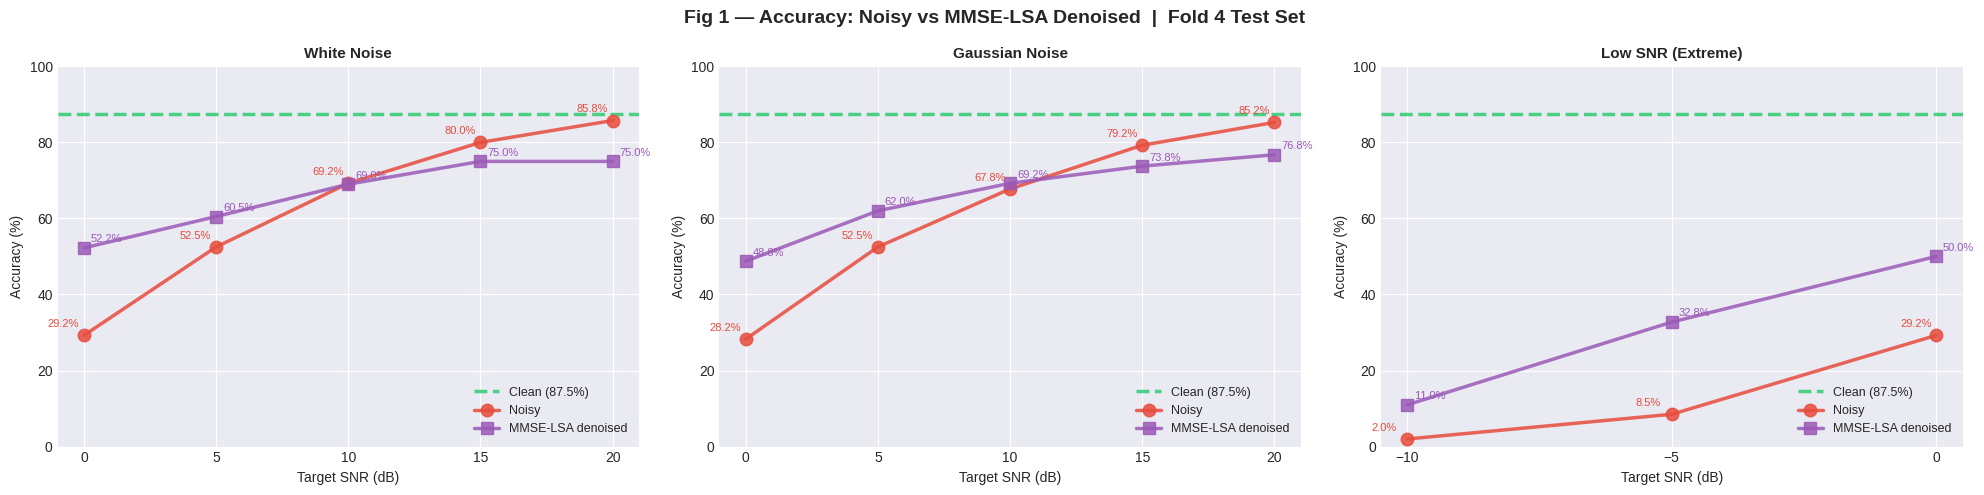

  ✅ Fig 1 saved


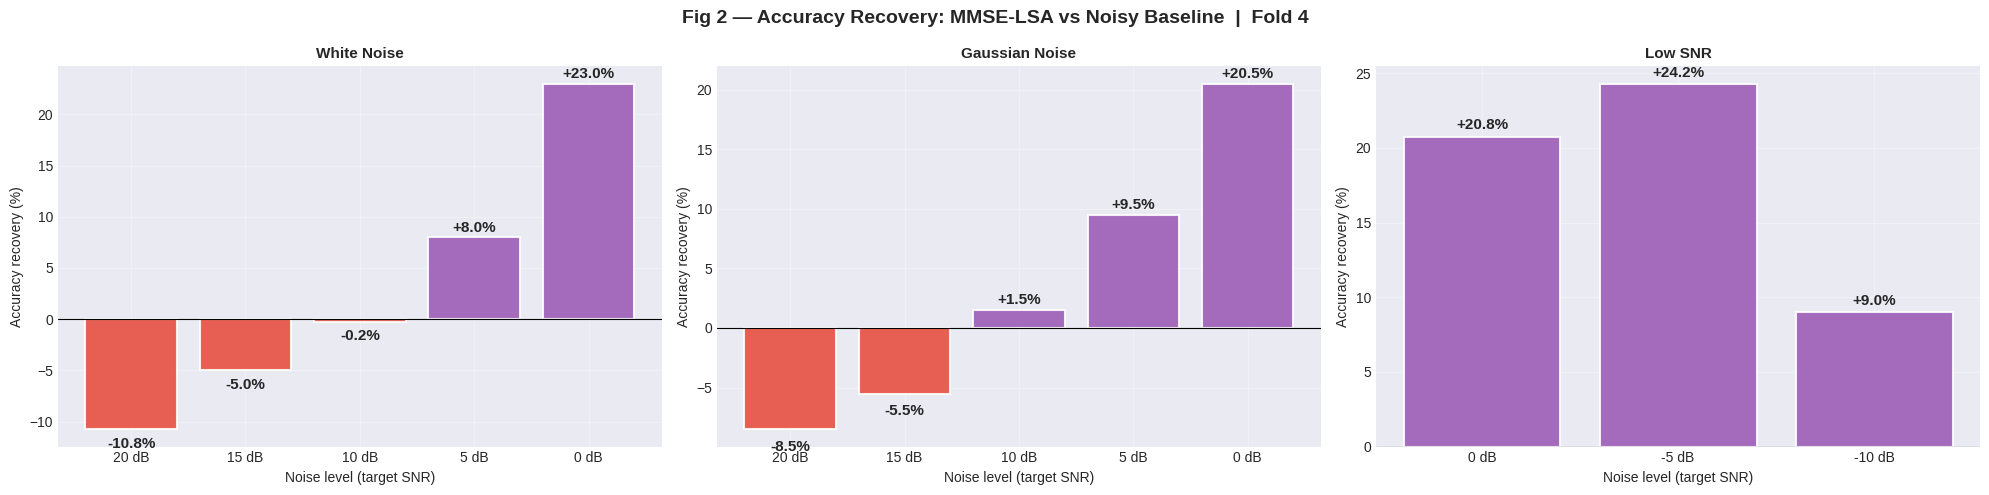

  ✅ Fig 2 saved


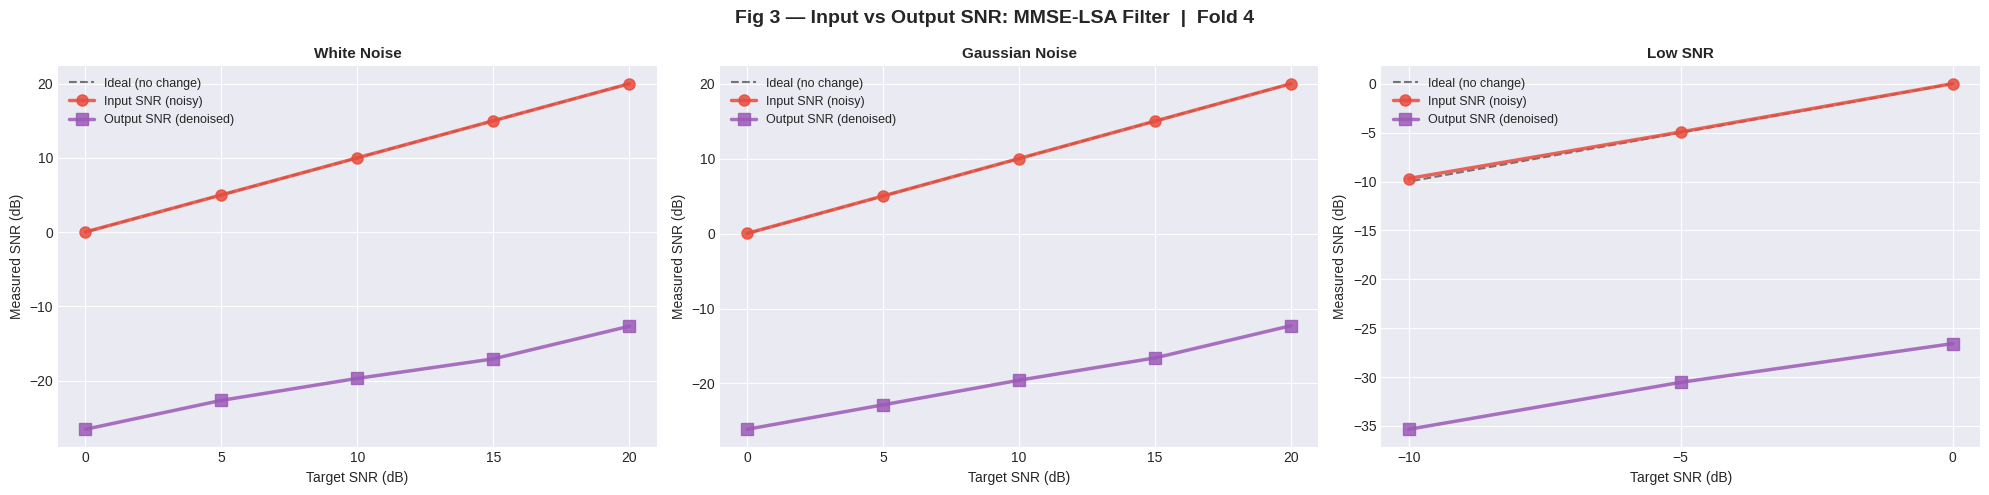

  ✅ Fig 3 saved


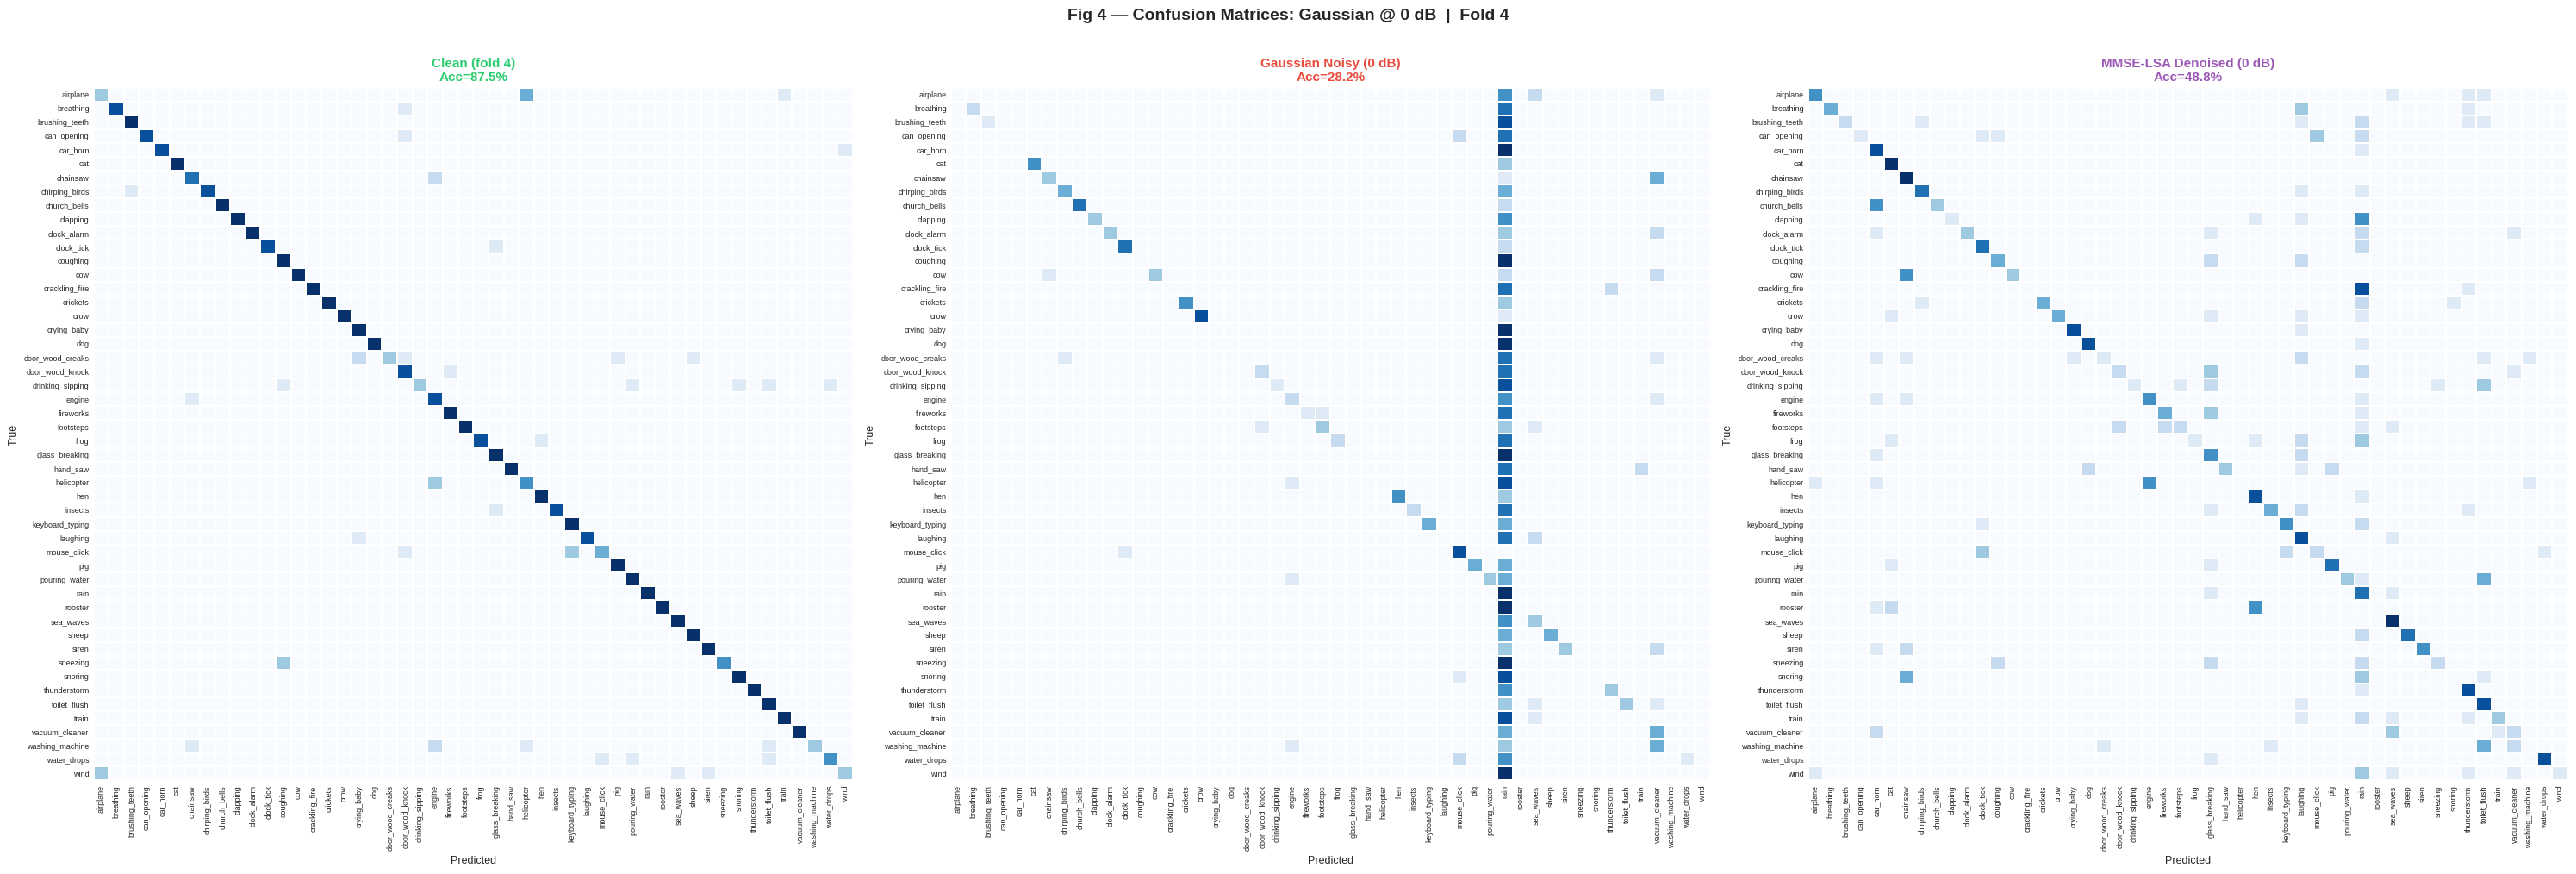

  ✅ Fig 4 saved

✅ JSON results saved: /content/drive/MyDrive/DSP Project/overfitting_check/results/noise_experiment_results.json

  FINAL SUMMARY — FOLD 4 NOISE EXPERIMENT
  Clean baseline: 87.50%

  WHITE NOISE
  Average recovery : +3.00%
  Best recovery    : +23.00%  @ 0 dB
      20dB  noisy=85.8%  →  mmse=75.0%  (-10.8%)  ⚠️  filter hurt
      15dB  noisy=80.0%  →  mmse=75.0%  (-5.0%)  ⚠️  filter hurt
      10dB  noisy=69.2%  →  mmse=69.0%  (-0.2%)
       5dB  noisy=52.5%  →  mmse=60.5%  (+8.0%)  ✅ strong improvement
       0dB  noisy=29.2%  →  mmse=52.2%  (+23.0%)  ✅ strong improvement

  GAUSSIAN NOISE
  Average recovery : +3.50%
  Best recovery    : +20.50%  @ 0 dB
      20dB  noisy=85.2%  →  mmse=76.8%  (-8.5%)  ⚠️  filter hurt
      15dB  noisy=79.2%  →  mmse=73.8%  (-5.5%)  ⚠️  filter hurt
      10dB  noisy=67.8%  →  mmse=69.2%  (+1.5%)
       5dB  noisy=52.5%  →  mmse=62.0%  (+9.5%)  ✅ strong improvement
       0dB  noisy=28.2%  →  mmse=48.8%  (+20.5%)  ✅ strong improvement


In [ ]:
# ── Summary stats ─────────────────────────────────────────────────────────────

def acc(col):
    return (df_res[col] == df_res['true_idx']).mean() * 100

acc_clean = acc('pred_clean')


def build_summary(noise_key, snr_levels, pred_suffix='mmse'):
    rows = []
    for snr in snr_levels:
        acc_n = acc(f'pred_{noise_key}_noisy_{snr}dB')
        acc_d = acc(f'pred_{noise_key}_{pred_suffix}_{snr}dB')
        snr_i = df_res[f'snr_in_{noise_key}_{snr}dB'].mean()
        snr_o = df_res[f'snr_out_{noise_key}_{snr}dB'].mean()
        rows.append({
            'SNR_target'     : snr,
            'acc_noisy'      : acc_n,
            'acc_denoised'   : acc_d,
            'recovery'       : acc_d - acc_n,
            'mean_snr_in'    : snr_i,
            'mean_snr_out'   : snr_o,
            'snr_improvement': snr_o - snr_i,
        })
    return pd.DataFrame(rows)

white_df  = build_summary('white',  WHITE_SNR_LEVELS)
gauss_df  = build_summary('gauss',  GAUSSIAN_SNR_LEVELS)
low_df    = build_summary('low',    LOW_SNR_LEVELS)


def print_table(name, sdf):
    print(f"\n  {name}")
    print(f"  {'SNR':>6} | {'Noisy%':>7} | {'MMSE%':>7} | "
          f"{'Recovery':>9} | {'SNR_in':>7} | {'SNR_out':>8} | {'ΔSNR':>7}")
    print(f"  {'─'*70}")
    for _, r in sdf.iterrows():
        print(f"  {int(r.SNR_target):>4}dB | "
              f"{r.acc_noisy:>6.2f}% | "
              f"{r.acc_denoised:>6.2f}% | "
              f"{r.recovery:>+8.2f}% | "
              f"{r.mean_snr_in:>6.2f}dB | "
              f"{r.mean_snr_out:>7.2f}dB | "
              f"{r.snr_improvement:>+6.2f}dB")

print(f"\n{'='*72}")
print(f"  NOISE EXPERIMENT — FOLD {OUTER_TEST_FOLD} RESULTS")
print(f"  Model : CNN14  |  Test set : {len(df_res)} clips, 50 classes")
print(f"  Filter: Decision-Directed MMSE-LSA  (α={DD_ALPHA}, β={DD_BETA})")
print(f"{'='*72}")
print(f"\n  CLEAN BASELINE: {acc_clean:.2f}%")
print_table("WHITE NOISE  (uniform spectrum)", white_df)
print_table("GAUSSIAN NOISE  (AWGN / thermal)", gauss_df)
print_table("LOW SNR — EXTREME  (Gaussian)", low_df)


# ── Figures ───────────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')


# Fig 1 — Accuracy vs SNR (3 panels)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

def _plot_acc(ax, sdf, snr_levels, title):
    ax.axhline(acc_clean, color=COLORS['clean'], lw=2.5, ls='--',
               label=f'Clean ({acc_clean:.1f}%)', alpha=0.85)
    ax.plot(sdf['SNR_target'], sdf['acc_noisy'],
            'o-', color=COLORS['noisy'],  lw=2.5, ms=9,
            label='Noisy', alpha=0.85)
    ax.plot(sdf['SNR_target'], sdf['acc_denoised'],
            's-', color=COLORS['mmse'],   lw=2.5, ms=9,
            label='MMSE-LSA denoised', alpha=0.85)
    for _, r in sdf.iterrows():
        ax.annotate(f"{r.acc_noisy:.1f}%",
                    (r.SNR_target, r.acc_noisy),
                    textcoords='offset points', xytext=(-26, 6),
                    fontsize=8, color=COLORS['noisy'])
        ax.annotate(f"{r.acc_denoised:.1f}%",
                    (r.SNR_target, r.acc_denoised),
                    textcoords='offset points', xytext=(5, 4),
                    fontsize=8, color=COLORS['mmse'])
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Target SNR (dB)', fontsize=10)
    ax.set_ylabel('Accuracy (%)', fontsize=10)
    ax.set_xticks(snr_levels)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=9, loc='lower right')

_plot_acc(axes[0], white_df,  WHITE_SNR_LEVELS,    "White Noise")
_plot_acc(axes[1], gauss_df,  GAUSSIAN_SNR_LEVELS,  "Gaussian Noise")
_plot_acc(axes[2], low_df,    LOW_SNR_LEVELS,        "Low SNR (Extreme)")
fig.suptitle(
    f'Fig 1 — Accuracy: Noisy vs MMSE-LSA Denoised  |  Fold {OUTER_TEST_FOLD} Test Set',
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUT_RESULTS / 'noise_fig1_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Fig 1 saved")


# Fig 2 — Recovery bars
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

def _plot_recovery(ax, sdf, snr_levels, title):
    bars = ax.bar(
        [f'{s} dB' for s in snr_levels],
        sdf['recovery'],
        color=[COLORS['mmse'] if r >= 0 else COLORS['noisy']
               for r in sdf['recovery']],
        edgecolor='white', linewidth=1.5, alpha=0.88,
    )
    ax.axhline(0, color='black', lw=0.8)
    for bar, r in zip(bars, sdf['recovery']):
        offset = 0.5 if r >= 0 else -1.8
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + offset,
                f'{r:+.1f}%', ha='center',
                fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Noise level (target SNR)', fontsize=10)
    ax.set_ylabel('Accuracy recovery (%)', fontsize=10)
    ax.grid(True, alpha=0.3)

_plot_recovery(axes[0], white_df,  WHITE_SNR_LEVELS,    "White Noise")
_plot_recovery(axes[1], gauss_df,  GAUSSIAN_SNR_LEVELS,  "Gaussian Noise")
_plot_recovery(axes[2], low_df,    LOW_SNR_LEVELS,        "Low SNR")
fig.suptitle(
    f'Fig 2 — Accuracy Recovery: MMSE-LSA vs Noisy Baseline  |  Fold {OUTER_TEST_FOLD}',
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUT_RESULTS / 'noise_fig2_recovery.png'), dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Fig 2 saved")


# Fig 3 — Input vs Output SNR
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

def _plot_snr(ax, sdf, snr_levels, title):
    ax.plot(snr_levels, snr_levels,
            'k--', lw=1.5, label='Ideal (no change)', alpha=0.5)
    ax.plot(sdf['SNR_target'], sdf['mean_snr_in'],
            'o-', color=COLORS['noisy'],  lw=2.5, ms=8,
            label='Input SNR (noisy)', alpha=0.85)
    ax.plot(sdf['SNR_target'], sdf['mean_snr_out'],
            's-', color=COLORS['mmse'],   lw=2.5, ms=8,
            label='Output SNR (denoised)', alpha=0.85)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Target SNR (dB)', fontsize=10)
    ax.set_ylabel('Measured SNR (dB)', fontsize=10)
    ax.set_xticks(snr_levels)
    ax.legend(fontsize=9)

_plot_snr(axes[0], white_df,  WHITE_SNR_LEVELS,    "White Noise")
_plot_snr(axes[1], gauss_df,  GAUSSIAN_SNR_LEVELS,  "Gaussian Noise")
_plot_snr(axes[2], low_df,    LOW_SNR_LEVELS,        "Low SNR")
fig.suptitle(
    f'Fig 3 — Input vs Output SNR: MMSE-LSA Filter  |  Fold {OUTER_TEST_FOLD}',
    fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUT_RESULTS / 'noise_fig3_snr.png'), dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Fig 3 saved")


# Fig 4 — Confusion matrices at worst SNR (Gaussian 0 dB)
idx_to_label_map = {v: k for k, v in label_to_idx.items()}
labels_50 = [idx_to_label_map[i] for i in range(50)]

fig, axes = plt.subplots(1, 3, figsize=(30, 10))
for ax, col, title, color in zip(
    axes,
    ['pred_clean',
     'pred_gauss_noisy_0dB',
     'pred_gauss_mmse_0dB'],
    [f'Clean (fold {OUTER_TEST_FOLD})',
     'Gaussian Noisy (0 dB)',
     'MMSE-LSA Denoised (0 dB)'],
    [COLORS['clean'], COLORS['noisy'], COLORS['mmse']],
):
    cm = confusion_matrix(df_res['true_idx'], df_res[col],
                          labels=list(range(50)))
    sns.heatmap(cm, ax=ax, cmap='Blues', cbar=False,
                xticklabels=labels_50, yticklabels=labels_50,
                linewidths=0.2)
    acc_val = (df_res[col] == df_res['true_idx']).mean() * 100
    ax.set_title(f'{title}\nAcc={acc_val:.1f}%',
                 fontsize=11, fontweight='bold', color=color)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True', fontsize=9)
    ax.tick_params(axis='x', rotation=90, labelsize=6.5)
    ax.tick_params(axis='y', rotation=0,  labelsize=6.5)

plt.suptitle(
    f'Fig 4 — Confusion Matrices: Gaussian @ 0 dB  |  Fold {OUTER_TEST_FOLD}',
    fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(str(OUT_RESULTS / 'noise_fig4_confusion.png'), dpi=120, bbox_inches='tight')
plt.show()
print("  ✅ Fig 4 saved")


# ── Save JSON results ─────────────────────────────────────────────────────────

def df_to_dict(sdf, snr_levels):
    out = []
    for _, r in sdf.iterrows():
        out.append({k: round(float(v), 4) for k, v in r.items()})
    return out

noise_summary = {
    "experiment"      : "noise_denoising",
    "model"           : "CNN14",
    "test_fold"       : int(OUTER_TEST_FOLD),
    "n_clips"         : int(len(df_res)),
    "filter"          : "Decision-Directed MMSE-LSA",
    "filter_params"   : {
        "alpha"        : DD_ALPHA,
        "beta"         : DD_BETA,
        "init_frames"  : DD_INIT_FRAMES,
        "gain_floor"   : DD_GAIN_FLOOR,
        "bypass_snr_db": DD_BYPASS_SNR_DB,
    },
    "clean_accuracy"  : round(acc_clean, 4),
    "white_noise"     : df_to_dict(white_df,  WHITE_SNR_LEVELS),
    "gaussian_noise"  : df_to_dict(gauss_df,  GAUSSIAN_SNR_LEVELS),
    "low_snr"         : df_to_dict(low_df,    LOW_SNR_LEVELS),
}

json_path = OUT_RESULTS / 'noise_experiment_results.json'
with open(json_path, 'w') as f:
    json.dump(noise_summary, f, indent=2)

print(f"\n✅ JSON results saved: {json_path}")


# ── Final console summary ─────────────────────────────────────────────────────

print(f"\n{'='*72}")
print(f"  FINAL SUMMARY — FOLD {OUTER_TEST_FOLD} NOISE EXPERIMENT")
print(f"  Clean baseline: {acc_clean:.2f}%")
print(f"{'='*72}")

for name, sdf in [
    ("WHITE NOISE",       white_df),
    ("GAUSSIAN NOISE",    gauss_df),
    ("LOW SNR (extreme)", low_df),
]:
    avg_rec  = sdf['recovery'].mean()
    best_row = sdf.loc[sdf['recovery'].idxmax()]
    print(f"\n  {name}")
    print(f"  Average recovery : {avg_rec:+.2f}%")
    print(f"  Best recovery    : {best_row['recovery']:+.2f}%  @ {int(best_row['SNR_target'])} dB")
    for _, r in sdf.iterrows():
        flag = ""
        if r.recovery > 5:
            flag = "  ✅ strong improvement"
        elif r.recovery < -3:
            flag = "  ⚠️  filter hurt"
        print(f"    {int(r.SNR_target):>4}dB  noisy={r.acc_noisy:.1f}%  →  "
              f"mmse={r.acc_denoised:.1f}%  ({r.recovery:+.1f}%){flag}")

print(f"\n{'='*72}")
print(f"  Saved to: {OUT_RESULTS}")
print(f"  • noise_fig1_accuracy.png")
print(f"  • noise_fig2_recovery.png")
print(f"  • noise_fig3_snr.png")
print(f"  • noise_fig4_confusion.png")
print(f"  • noise_experiment_results.json")
print(f"{'='*72}")